In [1]:
from pathlib import Path
import os
import sys
from types import SimpleNamespace

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != 'link_prediction_gcn_pathway':
    candidate = PROJECT_DIR / 'link_prediction_gcn_pathway'
    if candidate.is_dir():
        PROJECT_DIR = candidate
    else:
        raise FileNotFoundError('Start Jupyter from link_prediction_gcn_pathway or its parent directory.')

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))
os.chdir(PROJECT_DIR)

from src.data_loader import load_graph_data
# from src.train import train_and_evaluate

print(f'Project directory: {PROJECT_DIR}')


Project directory: /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/link_prediction_gcn_pathway


In [2]:
config = {
    'input_size': None,
    'hidden_size': 16,
    'dim_latent': 128,
    'num_layers': 2,
    'do_train': True,
    'epochs': 200,
    'lr': 0.01,
    'seed': 42,
    'test_ratio': 0.10,
    'val_ratio': 0.10,
    'group_reciprocal_edges': True,
    'strict_feature_provenance': True,
}
args = SimpleNamespace(**config)

config


{'input_size': None,
 'hidden_size': 16,
 'dim_latent': 128,
 'num_layers': 2,
 'do_train': True,
 'epochs': 200,
 'lr': 0.01,
 'seed': 42,
 'test_ratio': 0.1,
 'val_ratio': 0.1,
 'group_reciprocal_edges': True,
 'strict_feature_provenance': True}

In [3]:
GRAPH_PATH = PROJECT_DIR / 'data' / 'neo4j_graph_pass.json'
if not GRAPH_PATH.is_file():
    raise FileNotFoundError(f'Graph data file not found: {GRAPH_PATH}')

G_dgl, node_features = load_graph_data(str(GRAPH_PATH))
print(f'Graph file: {GRAPH_PATH}')
print(f'NumNodes: {G_dgl.num_nodes()}')
print(f'NumEdges: {G_dgl.num_edges()}')
print(f'NumFeats: {node_features.size(1)}')


Graph file: /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/link_prediction_gcn_pathway/data/neo4j_graph_pass.json
NumNodes: 17440
NumEdges: 36773
NumFeats: 64


In [4]:
import numpy as np
import torch
from tqdm.auto import tqdm


def compute_relevance_scores(
    model,
    graph,
    features,
    node_indices=None,
    method="saliency",
    use_abs=True,
    baseline=None,
    steps=50,
):
    """
    Compute node-feature relevance scores using Saliency or Integrated Gradients.

    Parameters
    ----------
    model : torch.nn.Module
        Trained GNN model. It must support ``model(graph, features)`` and
        return one logit per node.
    graph : dgl.DGLGraph
        Input graph.
    features : torch.Tensor or np.ndarray
        Input node features with shape [num_nodes, num_features].
    node_indices : list, torch.Tensor, or None
        Nodes for which relevance is computed. If None, nodes with sigmoid
        probability > 0 are selected.
    method : {"saliency", "integrated_gradients"}
        Attribution method.
    use_abs : bool
        Return absolute relevance values when True.
    baseline : torch.Tensor or np.ndarray or None
        IG baseline. Defaults to an all-zero tensor.
    steps : int
        Number of interpolation steps for Integrated Gradients.

    Returns
    -------
    torch.Tensor
        Relevance scores with shape [num_nodes, num_features]. Nodes not
        included in ``node_indices`` remain zero.
    """
    if method not in {"saliency", "integrated_gradients"}:
        raise ValueError(
            f"Unknown method: {method}. "
            "Use 'saliency' or 'integrated_gradients'."
        )

    if steps < 1:
        raise ValueError("steps must be >= 1 for integrated gradients.")

    model.eval()

    if isinstance(features, np.ndarray):
        features = torch.tensor(features, dtype=torch.float32)
    elif not torch.is_tensor(features):
        features = torch.tensor(features, dtype=torch.float32)
    else:
        features = features.detach().clone()

    # Keep features on the same device as the model.
    try:
        model_device = next(model.parameters()).device
        features = features.to(model_device)
    except StopIteration:
        pass

    features.requires_grad_(True)

    if baseline is not None:
        if isinstance(baseline, np.ndarray):
            baseline_input = torch.tensor(
                baseline, dtype=features.dtype, device=features.device
            )
        else:
            baseline_input = baseline.detach().clone().to(
                device=features.device, dtype=features.dtype
            )
        if baseline_input.shape != features.shape:
            raise ValueError(
                f"baseline shape {tuple(baseline_input.shape)} does not match "
                f"features shape {tuple(features.shape)}."
            )
    else:
        baseline_input = torch.zeros_like(features)

    with torch.enable_grad():
        logits = model(graph, features)
        probs = torch.sigmoid(logits.squeeze())

        if probs.ndim != 1:
            probs = probs.reshape(-1)

        if node_indices is None:
            node_indices = torch.nonzero(
                probs > 0.0, as_tuple=False
            ).flatten()
        else:
            node_indices = torch.as_tensor(
                node_indices, dtype=torch.long, device=features.device
            ).flatten()

        relevance_scores = torch.zeros_like(features)

        for i, idx in enumerate(
            tqdm(
                node_indices,
                desc=f"Computing relevance ({method})",
                leave=True,
            )
        ):
            idx = int(idx.item())

            if method == "saliency":
                model.zero_grad(set_to_none=True)
                if features.grad is not None:
                    features.grad.zero_()

                retain = i != len(node_indices) - 1
                probs[idx].backward(retain_graph=retain)

                grads = features.grad[idx]
                relevance_scores[idx] = (
                    grads.abs().detach() if use_abs else grads.detach()
                )

            else:
                # Integrated Gradients:
                # (x - baseline) * average gradient along the path.
                total_grad = torch.zeros_like(features)

                for alpha in torch.linspace(
                    1.0 / steps,
                    1.0,
                    steps,
                    device=features.device,
                    dtype=features.dtype,
                ):
                    scaled_input = (
                        baseline_input
                        + alpha * (features.detach() - baseline_input)
                    ).detach().requires_grad_(True)

                    model.zero_grad(set_to_none=True)
                    out = model(graph, scaled_input)
                    prob = torch.sigmoid(out.squeeze())[idx]

                    grad = torch.autograd.grad(
                        prob,
                        scaled_input,
                        retain_graph=False,
                        create_graph=False,
                    )[0]
                    total_grad += grad.detach()

                avg_grad = total_grad / steps
                ig = (features.detach() - baseline_input) * avg_grad

                relevance_scores[idx] = (
                    ig[idx].abs().detach() if use_abs else ig[idx].detach()
                )

    return relevance_scores.detach()



def load_or_build_enrichment_matrix(df_enrich, output_path):
    os.makedirs(output_path, exist_ok=True)

    mat_path = os.path.join(output_path, "enrich_matrix.npy")
    gene_path = os.path.join(output_path, "enrich_genes.npy")
    pathway_path = os.path.join(output_path, "enrich_pathways.npy")

    if (
        os.path.exists(mat_path) and
        os.path.exists(gene_path) and
        os.path.exists(pathway_path)
    ):
        print("✅ Loading saved enrichment matrix")
        enrich_matrix = np.load(mat_path)
        gene_names = np.load(gene_path, allow_pickle=True).tolist()
        pathway_names = np.load(pathway_path, allow_pickle=True).tolist()
        return enrich_matrix, gene_names, pathway_names

    print("🔄 Building enrichment matrix")

    gene_names = sorted(df_enrich["Gene2"].astype(str).unique())
    pathway_names = sorted(df_enrich["PathwayB"].astype(str).unique())

    gene_to_idx = {g: i for i, g in enumerate(gene_names)}
    pathway_to_idx = {p: i for i, p in enumerate(pathway_names)}

    enrich_matrix = np.zeros(
        (len(gene_names), len(pathway_names)),
        dtype=np.float32
    )

    for _, row in tqdm(
        df_enrich.iterrows(),
        total=len(df_enrich),
        desc="Building enrichment matrix"
    ):
        enrich_matrix[
            gene_to_idx[str(row["Gene2"])],
            pathway_to_idx[str(row["PathwayB"])]
        ] = row["enrich_score"]

    np.save(mat_path, enrich_matrix)
    np.save(gene_path, np.array(gene_names, dtype=object))
    np.save(pathway_path, np.array(pathway_names, dtype=object))

    print("✅ Enrichment matrix saved")

    return enrich_matrix, gene_names, pathway_names


In [5]:
# =========================
# Standard library
# =========================
import os
from matplotlib.patches import Patch
import math
import json
import itertools
from collections import defaultdict
from matplotlib.gridspec import GridSpec
from itertools import combinations
from tqdm import tqdm
from typing import Dict, List, Optional
from mpl_toolkits.mplot3d import Axes3D
# =========================
# Numerical / scientific
# =========================
from matplotlib.colors import to_rgb
import warnings
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

from sklearn.manifold import TSNE
import colorcet as cc
import umap.umap_ as umap
import os
import numpy as np
import pandas as pd
import torch
from collections import defaultdict
import igraph as ig
import leidenalg
from tqdm import tqdm
from matplotlib.ticker import LogFormatterMathtext

import igraph as ig
import leidenalg
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.stats import sem
from matplotlib.colors import LogNorm
# =========================
# Deep learning / graphs
# =========================
import torch
import dgl
import networkx as nx
from matplotlib.ticker import FuncFormatter
# =========================
# Models
# =========================
from src.models import (
    GCNModel,
    GINNetModel,
    ChebNetModel,
    MLPPredictor,
    FocalLoss,
)
from matplotlib.colors import PowerNorm

# =========================
# Evaluation utilities
# =========================
from src.utils import (
    compute_loss,
    compute_hits_k,
    compute_auc,
    compute_f1,
    compute_accuracy,
    compute_precision,
    compute_recall,
    compute_map,
    compute_focalloss,
    compute_focalloss_with_symmetrical_confidence,
    compute_auc_with_symmetrical_confidence,
    compute_f1_with_symmetrical_confidence,
    compute_accuracy_with_symmetrical_confidence,
    compute_precision_with_symmetrical_confidence,
    compute_recall_with_symmetrical_confidence,
    compute_map_with_symmetrical_confidence,
)

# =========================
# Clustering / embeddings
# =========================
from sklearn.cluster import SpectralBiclustering
import umap

# =========================
# Plotting
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# =========================
# Survival analysis
# =========================
from lifelines import (
    KaplanMeierFitter,
    CoxPHFitter,
    NelsonAalenFitter,
)
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index

from sksurv.util import Surv
from sksurv.metrics import (
    concordance_index_ipcw,
    cumulative_dynamic_auc,
)

# =========================
# Interactive visualization
# =========================
import plotly.graph_objects as go
CLUSTER_COLORS = {
    0: '#0077B6',   1: '#0000FF',   2: '#00B4D8',   3: '#48EAC4',
    4: '#F1C0E8',   5: '#B9FBC0',   6: '#32CD32',   7: '#bee1e6',
    8: '#8A2BE2',   9: '#E377C2',  10: '#8EECF5',  11: '#A3C4F3',
    12: '#FFB347', 13: '#FFD700',  14: '#FF69B4',  15: '#CD5C5C',
    16: '#7FFFD4', 17: '#FF7F50',  18: '#C71585',  19: '#20B2AA', 
    20: "#48CAE4", 21: "#90DBF4",  22: "#0077B6",  23: "#00B4D8"
}

import os
import numpy as np
import scipy.sparse as sp
import torch

# Pipeline note:
# The long-running computation is split into separate Jupyter cells below.
# Run them sequentially so each stage has its own visible tqdm/progress output.


In [6]:
# ============================================================
# Jupyter display configuration
# ============================================================
%matplotlib inline

import matplotlib.pyplot as plt
from IPython.display import display, Image as IPyImage, Markdown

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.figsize": (9, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

print("Jupyter plotting configured: matplotlib inline + saved-figure gallery enabled.")


Jupyter plotting configured: matplotlib inline + saved-figure gallery enabled.


In [8]:
import json
import networkx as nx
import dgl
import torch

def load_graph_data(file_path):
    # Load data from JSON file
    with open(file_path, 'r') as file:
        data = json.load(file)

    # Create a directed graph
    G_nx = nx.DiGraph()

    # Create a mapping for edge types to numerical values
    edge_type_mapping = {}

    # Iterate over the data and add nodes and edges
    for item in data:
        source = item['n']
        target = item['m']
        relationship_type = item['r']['type']

        # Add source and target nodes
        source_name = source['properties']['name']
        target_name = target['properties']['name']
        G_nx.add_node(source_name, **source['properties'])
        G_nx.add_node(target_name, **target['properties'])

        # Add edge with numerical type
        if relationship_type not in edge_type_mapping:
            edge_type_mapping[relationship_type] = len(edge_type_mapping)
        G_nx.add_edge(source_name, target_name, type=edge_type_mapping[relationship_type])  

    # Convert the NetworkX graph to a DGL graph
    G_dgl = dgl.from_networkx(G_nx, edge_attrs=['type'])

    # Extract node features
    node_features = torch.tensor([node[1]['embedding'] for node in G_nx.nodes(data=True)], dtype=torch.float32)
    G_dgl.ndata['feat'] = node_features

    return G_dgl, node_features


In [ ]:
# ============================================================
# Stage 1/9 — Leakage-safe edge split and model initialization
# ============================================================

print("Stage 1/9 — Leakage-safe edge split and model initialization")

import random
from collections import defaultdict

SEED = args.seed
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_nodes = G_dgl.number_of_nodes()
num_edges = G_dgl.number_of_edges()
u_np, v_np = [a.detach().cpu().numpy().astype(np.int64) for a in G_dgl.edges()]

edge_groups = defaultdict(list)

for eid, (src, dst) in enumerate(zip(u_np, v_np)):
    if args.group_reciprocal_edges:
        key = tuple(sorted((int(src), int(dst))))
    else:
        key = (int(src), int(dst))
    edge_groups[key].append(eid)

groups = list(edge_groups.values())
rng = np.random.default_rng(SEED)
rng.shuffle(groups)

n_groups = len(groups)
test_group_n = max(1, int(round(n_groups * args.test_ratio)))
val_group_n = max(1, int(round(n_groups * args.val_ratio)))

test_groups = groups[:test_group_n]
val_groups = groups[test_group_n:test_group_n + val_group_n]
train_groups = groups[test_group_n + val_group_n:]

test_eids = np.array([eid for group in test_groups for eid in group], dtype=np.int64)
val_eids = np.array([eid for group in val_groups for eid in group], dtype=np.int64)
train_eids = np.array([eid for group in train_groups for eid in group], dtype=np.int64)

rng.shuffle(test_eids)
rng.shuffle(val_eids)
rng.shuffle(train_eids)

assert len(set(train_eids) & set(val_eids)) == 0
assert len(set(train_eids) & set(test_eids)) == 0
assert len(set(val_eids) & set(test_eids)) == 0

train_pos_u, train_pos_v = u_np[train_eids], v_np[train_eids]
val_pos_u, val_pos_v = u_np[val_eids], v_np[val_eids]
test_pos_u, test_pos_v = u_np[test_eids], v_np[test_eids]

# ------------------------------------------------------------
# 3. Construct negatives from the COMPLETE edge set, then split
# ------------------------------------------------------------
# No negative edge is allowed to overlap a positive edge.
# Negative splits are disjoint from each other.
positive_pairs = set(zip(u_np.tolist(), v_np.tolist()))
if args.group_reciprocal_edges:
    positive_pairs |= set((b, a) for a, b in positive_pairs)

negative_candidates = []
for src in range(num_nodes):
    for dst in range(num_nodes):
        if src == dst:
            continue
        if (src, dst) not in positive_pairs:
            negative_candidates.append((src, dst))

negative_candidates = np.asarray(negative_candidates, dtype=np.int64)
rng.shuffle(negative_candidates)

n_test_neg = len(test_eids)
n_val_neg = len(val_eids)
n_train_neg = len(train_eids)

if len(negative_candidates) < n_test_neg + n_val_neg + n_train_neg:
    raise RuntimeError("Not enough non-edge candidates for the requested negative split.")

test_neg = negative_candidates[:n_test_neg]
val_neg = negative_candidates[n_test_neg:n_test_neg + n_val_neg]
train_neg = negative_candidates[n_test_neg + n_val_neg:n_test_neg + n_val_neg + n_train_neg]

train_pos = torch.as_tensor(np.column_stack([train_pos_u, train_pos_v]), dtype=torch.long, device=device)
val_pos = torch.as_tensor(np.column_stack([val_pos_u, val_pos_v]), dtype=torch.long, device=device)
test_pos = torch.as_tensor(np.column_stack([test_pos_u, test_pos_v]), dtype=torch.long, device=device)

train_neg = torch.as_tensor(train_neg, dtype=torch.long, device=device)
val_neg = torch.as_tensor(val_neg, dtype=torch.long, device=device)
test_neg = torch.as_tensor(test_neg, dtype=torch.long, device=device)

# ------------------------------------------------------------
# 4. Training graph: ONLY training positive edges
# ------------------------------------------------------------
# This is the graph supplied to the GNN during fitting, validation,
# test prediction, and attribution. Held-out positives are absent.
train_g = dgl.graph(
    (torch.as_tensor(train_pos_u), torch.as_tensor(train_pos_v)),
    num_nodes=num_nodes
)

train_g = dgl.add_self_loop(train_g)
train_g = train_g.to(device)

x = torch.as_tensor(node_features, dtype=torch.float32, device=device)
train_g.ndata["feat"] = x

# Keep a no-self-loop copy for explicit edge-membership checks.
train_g_no_loop = dgl.remove_self_loop(train_g)

# ------------------------------------------------------------
# 5. Leakage assertions
# ------------------------------------------------------------
train_edge_set = set(zip(train_pos_u.tolist(), train_pos_v.tolist()))
val_edge_set = set(zip(val_pos_u.tolist(), val_pos_v.tolist()))
test_edge_set = set(zip(test_pos_u.tolist(), test_pos_v.tolist()))

assert not (train_edge_set & val_edge_set)
assert not (train_edge_set & test_edge_set)

if args.group_reciprocal_edges:
    train_undirected = {tuple(sorted(e)) for e in train_edge_set}
    val_undirected = {tuple(sorted(e)) for e in val_edge_set}
    test_undirected = {tuple(sorted(e)) for e in test_edge_set}
    assert not (train_undirected & val_undirected)
    assert not (train_undirected & test_undirected)

# Prediction graphs contain candidate edges only; they are NOT used for
# message passing. Message passing always uses train_g.
train_pos_g = dgl.graph(
    (train_pos[:, 0], train_pos[:, 1]),
    num_nodes=num_nodes,
    device=device
)
train_neg_g = dgl.graph(
    (train_neg[:, 0], train_neg[:, 1]),
    num_nodes=num_nodes,
    device=device
)

# ------------------------------------------------------------
# 6. Model, predictor, loss, optimizer
# ------------------------------------------------------------
model = GCNModel(
    node_features.shape[1],
    dim_latent=args.dim_latent,
    num_layers=args.num_layers,
    do_train=True
).to(device)

# pred = MLPPredictor(
#     args.input_size,
#     args.hidden_size
# ).to(device)

pred = MLPPredictor(
    input_size=2 * args.dim_latent,
    hidden_size=args.hidden_size
).to(device)

criterion = FocalLoss(alpha=0.25, gamma=2.0)

optimizer = torch.optim.Adam(
    itertools.chain(model.parameters(), pred.parameters()),
    lr=args.lr
)

output_path = "link_prediction_gcn/results_leakage_fixed/"
os.makedirs(output_path, exist_ok=True)

# Save the split itself so the experiment is reproducible.
np.savez(
    os.path.join(output_path, "leakage_safe_edge_split.npz"),
    train_pos=np.column_stack([train_pos_u, train_pos_v]),
    val_pos=np.column_stack([val_pos_u, val_pos_v]),
    test_pos=np.column_stack([test_pos_u, test_pos_v]),
    train_neg=train_neg.detach().cpu().numpy(),
    val_neg=val_neg.detach().cpu().numpy(),
    test_neg=test_neg.detach().cpu().numpy(),
)

print("\nStage 1/9 completed.")
print(f"Device: {device}")
print(f"Nodes: {num_nodes:,}")
print(f"Original edges: {num_edges:,}")
print(f"Train positive edges: {len(train_pos):,}")
print(f"Validation positive edges: {len(val_pos):,}")
print(f"Test positive edges: {len(test_pos):,}")
print(f"Train graph edges: {train_g_no_loop.num_edges():,}")
print(f"Reciprocal grouping: {args.group_reciprocal_edges}")
print("Leakage assertions: PASSED")


Stage 1/9 — Leakage-safe edge split and model initialization

Stage 1/9 completed.
Device: cpu
Nodes: 17,440
Original edges: 36,773
Train positive edges: 29,419
Validation positive edges: 3,678
Test positive edges: 3,676
Train graph edges: 29,418
Reciprocal grouping: True
Leakage assertions: PASSED


In [ ]:
# Stage 2/9 — Train GCN
print('Stage 2/9 — Train GCN')

pbar = tqdm(
    range(args.epochs),
    desc="Training GCN",
    unit="epoch",
    dynamic_ncols=True,
)

for e in pbar:
    model.train()

    h = model(train_g, train_g.ndata["feat"])
    pos_score = pred(train_pos_g, h)
    neg_score = pred(train_neg_g, h)

    labels = torch.cat([
        torch.ones_like(pos_score),
        torch.zeros_like(neg_score)
    ])
    scores = torch.cat([pos_score, neg_score])

    loss = criterion(scores, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Keep the loss on the same live progress bar instead of producing
    # hundreds of separate notebook output lines.
    pbar.set_postfix(loss=f"{loss.item():.4f}")

print(f"Training complete: {args.epochs} epochs.")
print('✓ Model training complete')


Stage 2/9 — Train GCN


Training GCN: 100%|██████████| 200/200 [00:28<00:00,  7.09epoch/s, loss=0.0313]

Training complete: 200 epochs.
✓ Model training complete


## 4.2b Leakage-safe validation/test evaluation
Evaluate held-out edges using node representations computed from **train_g only**. The test split is not used for model fitting, model selection, clustering, or attribution.


In [11]:
# ============================================================
# Leakage-safe validation/test evaluation
# ============================================================

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, precision_score, recall_score

def score_edges(model, predictor, graph, features, pos_edges, neg_edges):
    model.eval()
    predictor.eval()
    with torch.no_grad():
        h = model(graph, features)
        pos_graph = dgl.graph(
            (pos_edges[:, 0], pos_edges[:, 1]),
            num_nodes=graph.num_nodes(),
            device=graph.device
        )
        neg_graph = dgl.graph(
            (neg_edges[:, 0], neg_edges[:, 1]),
            num_nodes=graph.num_nodes(),
            device=graph.device
        )
        pos_score = predictor(pos_graph, h).reshape(-1)
        neg_score = predictor(neg_graph, h).reshape(-1)

    y_true = torch.cat([
        torch.ones_like(pos_score),
        torch.zeros_like(neg_score)
    ]).detach().cpu().numpy()

    y_prob = torch.sigmoid(torch.cat([pos_score, neg_score])).detach().cpu().numpy()
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "AUROC": roc_auc_score(y_true, y_prob),
        "AUPRC": average_precision_score(y_true, y_prob),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
    }

# Validation is reported, but no test metric is used during training.
val_metrics = score_edges(model, pred, train_g, x, val_pos, val_neg)
test_metrics = score_edges(model, pred, train_g, x, test_pos, test_neg)

metrics_df = pd.DataFrame(
    [val_metrics, test_metrics],
    index=["validation", "test"]
)
metrics_df.to_csv(os.path.join(output_path, "leakage_safe_metrics.csv"))

print("Leakage-safe validation metrics:")
print(metrics_df.loc[["validation"]])
print("\nLeakage-safe final test metrics:")
print(metrics_df.loc[["test"]])


Leakage-safe validation metrics:
               AUROC     AUPRC        F1  Accuracy  Precision    Recall
validation  0.744945  0.780673  0.657725  0.719005   0.841169  0.539967

Leakage-safe final test metrics:
         AUROC     AUPRC        F1  Accuracy  Precision    Recall
test  0.739788  0.777032  0.642713  0.710555   0.839474  0.520675


In [13]:
def load_or_compute_relevance(
    model,
    graph,
    features,
    method="saliency",
    node_indices=None,
    use_abs=True,
    baseline=None,
    steps=50,
    cache_dir="results/relevance",
    force_recompute=False
):
    os.makedirs(cache_dir, exist_ok=True)

    fname = f"relevance_{method}.pt"
    fpath = os.path.join(cache_dir, fname)

    meta_path = os.path.join(cache_dir, "meta.json")

    # ---------- LOAD ----------
    if os.path.exists(fpath) and not force_recompute:
        print(f"📦 Loading cached relevance: {fpath}")
        relevance = torch.load(fpath, map_location="cpu")

        # Optional sanity check
        if relevance.shape[1] != features.shape[1]:
            raise ValueError("Cached relevance feature dim mismatch")

        return relevance

    # ---------- COMPUTE ----------
    print(f"🧠 Computing relevance ({method}) ...")
    relevance = compute_relevance_scores(
        model=model,
        graph=graph,
        features=features,
        node_indices=node_indices,
        method=method,
        use_abs=use_abs,
        baseline=baseline,
        steps=steps
    )

    # ---------- SAVE ----------
    torch.save(relevance.cpu(), fpath)

    meta = {
        "method": method,
        "use_abs": use_abs,
        "steps": steps,
        "num_nodes": relevance.shape[0],
        "num_features": relevance.shape[1]
    }

    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"💾 Relevance saved to {fpath}")

    return relevance

def edge_integrated_gradients_cached(
    h,
    u_idx,
    v_idx,
    predictor,
    output_path,
    steps=50,
    batch_size=4096,
    force_recompute=False
):
    os.makedirs(output_path, exist_ok=True)
    cache_file = os.path.join(output_path, "edge_ig.npy")

    if os.path.exists(cache_file) and not force_recompute:
        print("✅ Loading cached edge integrated gradients")
        return torch.from_numpy(np.load(cache_file))

    device = h.device
    E = u_idx.shape[0]
    ig_scores = []

    for i in tqdm(
        range(0, E, batch_size),
        desc="Edge Integrated Gradients (batched)",
        leave=True
    ):
        ub = u_idx[i:i + batch_size]
        vb = v_idx[i:i + batch_size]

        edge_embed = torch.cat([h[ub], h[vb]], dim=1)
        baseline = torch.zeros_like(edge_embed)
        total_grad = torch.zeros_like(edge_embed)

        alphas = torch.linspace(0, 1, steps, device=device)

        for alpha in alphas:
            interp = baseline + alpha * (edge_embed - baseline)
            interp.requires_grad_(True)

            predictor.zero_grad(set_to_none=True)
            predictor.forward_from_embedding(interp).sum().backward()

            total_grad += interp.grad.detach()

        avg_grad = total_grad / steps
        ig = (edge_embed - baseline) * avg_grad
        ig_scores.append(ig.abs().sum(dim=1))

    ig_scores = torch.cat(ig_scores).cpu().numpy()
    np.save(cache_file, ig_scores)

    print(f"✅ Saved edge IG → {cache_file}")

    return torch.from_numpy(ig_scores)


In [ ]:
# Stage 3/9 — Compute node and edge attribution
print("Stage 3/9 — Compute node and edge attribution")

relevance_scores = load_or_compute_relevance(
    model=model,
    graph=train_g,
    features=train_g.ndata["feat"],
    method="saliency",
    cache_dir=os.path.join(output_path, "relevance"),
    force_recompute=False
)

print("✓ Leakage-safe node-feature relevance computed")

gene_saliency = relevance_scores.sum(dim=1)
saliency_np = gene_saliency.detach().cpu().numpy()

model.eval()
with torch.no_grad():
    h_train = model(train_g, train_g.ndata["feat"])

u_train, v_train = train_g_no_loop.edges()

edge_ig = edge_integrated_gradients_cached(
    h=h_train,
    u_idx=u_train,
    v_idx=v_train,
    predictor=pred,
    output_path=output_path,
    steps=50,
    batch_size=4096
)

edge_ig_norm = (
    edge_ig - edge_ig.min()
) / (edge_ig.max() - edge_ig.min() + 1e-9)

pd.DataFrame({
    "Gene_u": u_train.detach().cpu().numpy(),
    "Gene_v": v_train.detach().cpu().numpy(),
    "IG_Score": edge_ig_norm
}).sort_values(
    "IG_Score", ascending=False
).to_csv(
    os.path.join(output_path, "edge_attributions_train_graph.csv"),
    index=False
)

print("✓ Edge attribution computed from training graph only")


Stage 3/9 — Compute node and edge attribution
📦 Loading cached relevance: link_prediction_gcn/results_leakage_fixed/relevance/relevance_saliency.pt
✓ Leakage-safe node-feature relevance computed
✅ Loading cached edge integrated gradients
✓ Edge attribution computed from training graph only


In [15]:
# ============================================================
# Leakage audit
# ============================================================

def canonical_edges(edges):
    return {tuple(sorted((int(a), int(b)))) for a, b in edges}

train_edges = set(zip(train_pos_u.tolist(), train_pos_v.tolist()))
val_edges = set(zip(val_pos_u.tolist(), val_pos_v.tolist()))
test_edges = set(zip(test_pos_u.tolist(), test_pos_v.tolist()))

print("Direct overlap:")
print("  train ∩ validation:", len(train_edges & val_edges))
print("  train ∩ test:      ", len(train_edges & test_edges))
print("  validation ∩ test: ", len(val_edges & test_edges))

assert not (train_edges & val_edges)
assert not (train_edges & test_edges)
assert not (val_edges & test_edges)

if args.group_reciprocal_edges:
    train_can = canonical_edges(train_edges)
    val_can = canonical_edges(val_edges)
    test_can = canonical_edges(test_edges)
    print("\nReciprocal/canonical overlap:")
    print("  train ∩ validation:", len(train_can & val_can))
    print("  train ∩ test:      ", len(train_can & test_can))
    assert not (train_can & val_can)
    assert not (train_can & test_can)

# Confirm the message-passing graph contains no held-out positive.
train_graph_edges = set(
    zip(
        train_g_no_loop.edges()[0].detach().cpu().tolist(),
        train_g_no_loop.edges()[1].detach().cpu().tolist()
    )
)
assert not (train_graph_edges & val_edges)
assert not (train_graph_edges & test_edges)

print("\n✓ Leakage audit PASSED")
print("✓ Validation/test positives are absent from the message-passing graph")
print("✓ Attribution is based on train_g only")


Direct overlap:
  train ∩ validation: 0
  train ∩ test:       0
  validation ∩ test:  0

Reciprocal/canonical overlap:
  train ∩ validation: 0
  train ∩ test:       0

✓ Leakage audit PASSED
✓ Validation/test positives are absent from the message-passing graph
✓ Attribution is based on train_g only


In [ ]:
def save_top_gene_pathway_pairs(
    saliency_pathway_matrix,
    gene_names,
    pathway_names,
    output_path,
    top_k=50
):
    import os
    import numpy as np
    import pandas as pd

    rows = []
    for p in range(len(pathway_names)):
        idx = np.argsort(saliency_pathway_matrix[p])[::-1][:top_k]
        for g in idx:
            rows.append([
                pathway_names[p],
                gene_names[g],
                saliency_pathway_matrix[p, g]
            ])

    pd.DataFrame(
        rows,
        columns=["Pathway", "Gene", "Saliency"]
    ).to_csv(
        os.path.join(output_path, "top_gene_pathway_pairs.csv"),
        index=False
    )

def save_cluster_pathway_gene_flows(
    saliency_pathway_matrix,
    row_labels,
    gene_names,
    pathway_names,
    output_path,
    top_k=50
):
    import os
    import numpy as np
    import pandas as pd

    flows = []
    for p, c in enumerate(row_labels):
        scores = saliency_pathway_matrix[p]
        idx = np.argsort(scores)[::-1][:top_k]
        for g in idx:
            if scores[g] > 0:
                flows.append([
                    f"Cluster {c}",
                    pathway_names[p],
                    gene_names[g],
                    scores[g]
                ])

    pd.DataFrame(
        flows,
        columns=["Cluster", "Pathway", "Gene", "Value"]
    ).to_csv(
        os.path.join(output_path, "sankey_cluster_pathway_gene.csv"),
        index=False
    )

def save_cluster_pathway_gene_flows(
    saliency_pathway_matrix,
    row_labels,
    gene_names,
    pathway_names,
    output_path,
    top_k=50
):
    import os
    import numpy as np
    import pandas as pd

    flows = []
    for p, c in enumerate(row_labels):
        scores = saliency_pathway_matrix[p]
        idx = np.argsort(scores)[::-1][:top_k]
        for g in idx:
            if scores[g] > 0:
                flows.append([
                    f"Cluster {c}",
                    pathway_names[p],
                    gene_names[g],
                    scores[g]
                ])

    pd.DataFrame(
        flows,
        columns=["Cluster", "Pathway", "Gene", "Value"]
    ).to_csv(
        os.path.join(output_path, "sankey_cluster_pathway_gene.csv"),
        index=False
    )

def assign_gene_clusters(gene_names, col_labels):
    import pandas as pd
    return pd.Series(col_labels, index=gene_names)

def align_expression_matrix(expr_path, gene_names):
    import pandas as pd

    expr_df = pd.read_csv(expr_path, sep="\t", index_col=0)
    common = sorted(set(expr_df.index).intersection(gene_names))
    return expr_df.loc[common].T.to_numpy(), common


def extract_gene_cluster_map(
    saliency_pathway_matrix,
    row_labels,
    top_k=50
):
    import numpy as np
    from collections import defaultdict

    m = defaultdict(set)
    for p, c in enumerate(row_labels):
        idx = np.argsort(saliency_pathway_matrix[p])[::-1][:top_k]
        for g in idx:
            m[c].add(g)
    return {k: list(v) for k, v in m.items()}

def leiden_bipartite_from_saliency(
    saliency_pathway_matrix,
    gene_names,
    pathway_names,
    resolution=1.2,
    weight_threshold=0.0
):
    n_pathways, n_genes = saliency_pathway_matrix.shape
    edges = []
    weights = []

    for p in range(n_pathways):
        row = saliency_pathway_matrix[p]
        nz = np.where(row > weight_threshold)[0]
        for g in nz:
            edges.append((p, n_pathways + g))
            weights.append(float(row[g]))

    g = ig.Graph(
        n=n_pathways + n_genes,
        edges=edges,
        edge_attrs={"weight": weights}
    )

    part = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        weights="weight",
        resolution_parameter=resolution
    )

    labels = np.array(part.membership)

    pathway_clusters = {
        pathway_names[i]: int(labels[i])
        for i in range(n_pathways)
    }

    gene_clusters = {
        gene_names[j]: int(labels[n_pathways + j])
        for j in range(n_genes)
    }

    return pathway_clusters, gene_clusters, labels

def plot_gene_umap(
    gene_embeddings,
    gene_names,
    gene_clusters,
    output_path
):
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=0
    )

    emb_2d = reducer.fit_transform(gene_embeddings)

    labels = np.array([gene_clusters[g] for g in gene_names])

    plt.figure(figsize=(7, 6))
    plt.scatter(
        emb_2d[:, 0],
        emb_2d[:, 1],
        c=labels,
        s=8,
        cmap="tab20"
    )

    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    plt.tight_layout()
    plt.savefig(
        os.path.join(output_path, "gene_umap_leiden.png"),
        dpi=300
    )
    plt.show()

def plot_top_genes_per_cluster(
    gene_saliency,
    gene_names,
    gene_clusters,
    output_path,
    top_k=10
):
    import os
    import pandas as pd
    import matplotlib.pyplot as plt

    os.makedirs(output_path, exist_ok=True)

    common_genes = [g for g in gene_names if g in gene_clusters]
    saliency_filtered = [
        gene_saliency[gene_names.index(g)] for g in common_genes
    ]

    df = pd.DataFrame({
        "gene": common_genes,
        "saliency": saliency_filtered,
        "cluster": [gene_clusters[g] for g in common_genes]
    })

    for c in sorted(df["cluster"].unique()):
        top = df[df["cluster"] == c].nlargest(top_k, "saliency")

        plt.figure(figsize=(5.5, 4.5))
        plt.barh(top["gene"], top["saliency"])

        # 🔹 Larger text
        plt.title(
            f"Top {top_k} Genes in Cluster {c}",
            fontsize=24,
            fontweight="bold",
            pad=10
        )
        plt.xlabel("Saliency Score", fontsize=13)
        plt.ylabel("Gene", fontsize=13)

        plt.xticks(fontsize=11)
        plt.yticks(fontsize=11)

        plt.gca().invert_yaxis()
        plt.tight_layout()

        plt.savefig(
            os.path.join(output_path, f"top_genes_cluster_{c}.png"),
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

def build_gene_cluster_map(gene_clusters):
    m = defaultdict(list)
    for g, c in gene_clusters.items():
        m[c].append(g)
    return dict(m)


def plot_leiden_saliency_heatmap(
    saliency_pathway_matrix,
    gene_names,
    pathway_names,
    gene_clusters,
    pathway_clusters,
    output_path,
    args,
    vmax_percentile=99,
    figsize=(16, 12),
):
    """
    Leiden-ordered gene–pathway saliency heatmap with cluster bars and log scaling.
    Output filename is automatically generated from args.
    """

    # ==========================================================
    # 0. Filename from args
    # ==========================================================
    leiden_heatmap_file = (
        f"leiden_gene_pathway_heatmap"
        f"_dim{args.dim_latent}"
        f"_lay{args.num_layers}"
        f"_hid{args.hidden_size}"
        f"_epo{args.epochs}.png"
    )


    # ==========================================================
    # 1. Leiden ordering
    # ==========================================================
    gene_order = sorted(
        range(len(gene_names)),
        key=lambda i: gene_clusters[gene_names[i]]
    )
    pathway_order = sorted(
        range(len(pathway_names)),
        key=lambda i: pathway_clusters[pathway_names[i]]
    )

    mat = saliency_pathway_matrix[np.ix_(pathway_order, gene_order)]
    vmax = np.percentile(mat, vmax_percentile)


    # ==========================================================
    # Log-scaled normalization (safe for zeros)
    # ==========================================================
    mat_plot = mat.copy()

    # Mask non-positive values (LogNorm cannot handle ≤ 0)
    mat_plot[mat_plot <= 0] = np.nan

    # Robust limits
    vmin = np.nanpercentile(mat_plot, 3)
    vmax = np.nanpercentile(mat_plot, vmax_percentile)

    # Safety guards
    vmin = max(vmin, 1e-6)
    vmax = max(vmax, vmin * 10)

    norm = LogNorm(vmin=vmin, vmax=vmax)

    # ==========================================================
    # 2. Cluster color bars (fixed palette)
    # ==========================================================
    gene_cluster_ids = [gene_clusters[gene_names[i]] for i in gene_order]
    pathway_cluster_ids = [pathway_clusters[pathway_names[i]] for i in pathway_order]

    def cluster_to_rgb(cid):
        if cid not in CLUSTER_COLORS:
            raise ValueError(f"Cluster ID {cid} not in CLUSTER_COLORS")
        return to_rgb(CLUSTER_COLORS[cid])

    gene_colors = np.array([cluster_to_rgb(c) for c in gene_cluster_ids])
    pathway_colors = np.array([cluster_to_rgb(c) for c in pathway_cluster_ids])


    # ==========================================================
    # 3. Layout
    # ==========================================================
    fig = plt.figure(figsize=figsize)

    gs = GridSpec(
        2, 3,
        width_ratios=[0.022, 0.92, 0.058],   # extra space for colorbar
        height_ratios=[0.03, 0.97],
        wspace=0.0,
        hspace=0.0,
    )

    ax_top  = fig.add_subplot(gs[0, 1])
    ax_left = fig.add_subplot(gs[1, 0])
    ax_main = fig.add_subplot(gs[1, 1])
    ax_cbar = fig.add_subplot(gs[1, 2])

    # avoid zeros (log-safe)
    mat_plot = np.clip(mat, 1e-4, None)

    vmin = np.percentile(mat_plot, 5)     # darker background
    vmax = np.percentile(mat_plot, 99)    # suppress outliers

    hm = sns.heatmap(
        mat_plot,
        ax=ax_main,
        cmap="mako",
        norm=LogNorm(vmin=vmin, vmax=vmax),
        xticklabels=False,
        yticklabels=False,
        cbar=True,
        cbar_ax=ax_cbar,
        rasterized=True,
    )


    ax_main.set_xlabel("")
    ax_main.set_ylabel("")

    cbar = hm.collections[0].colorbar
    cbar.set_label("")
    cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext())
    cbar.set_label("Saliency", fontsize=22, labelpad=14)
    cbar.ax.tick_params(labelsize=18)
    # ==========================================================
    # 5. Axis cluster bars
    # ==========================================================
    ax_top.imshow(gene_colors[None, :, :], aspect="auto")
    ax_top.set_axis_off()

    ax_left.imshow(pathway_colors[:, None, :], aspect="auto")
    ax_left.set_axis_off()

    # ==========================================================
    # 6. External text labels (clean, non-TeX-bold)
    # ==========================================================
    ax_top.text(
        0.5, 1.9,
        "Genes",
        ha="center",
        va="bottom",
        transform=ax_top.transAxes,
        fontsize=22,
    )

    ax_left.text(
        -1.8, 0.5,
        "Pathways",
        ha="center",
        va="center",
        rotation=90,
        transform=ax_left.transAxes,
        fontsize=22,
    )

    # ==========================================================
    # 7. Alignment + resized colorbar
    # ==========================================================
    fig.canvas.draw()
    main_pos = ax_main.get_position()
    cbar_pos = ax_cbar.get_position()

    # y-axis bar flush
    ax_left.set_position([
        ax_left.get_position().x0,
        main_pos.y0,
        ax_left.get_position().width,
        main_pos.height,
    ])

    # top bar aligned
    ax_top.set_position([
        main_pos.x0,
        ax_top.get_position().y0,
        main_pos.width,
        ax_top.get_position().height,
    ])

    # colorbar: farther, half width & half height
    new_h = main_pos.height * 0.5
    new_w = cbar_pos.width * 0.5

    ax_cbar.set_position([
        cbar_pos.x0 + 0.02,  # ← extra separation from heatmap
        main_pos.y0 + (main_pos.height - new_h) / 2,
        new_w,
        new_h,
    ])

    os.makedirs(output_path, exist_ok=True)

    plt.savefig(
        os.path.join(output_path, leiden_heatmap_file),
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.02,
    )
    plt.show()



Stage 4/9 — Build pathway saliency and clusters
✓ Enrichment data loaded
✅ Loading saved enrichment matrix
✓ Pathway enrichment matrix ready


Gene–Pathway saliency: 100%|██████████| 7210/7210 [00:01<00:00, 5105.69it/s]


✓ Gene-pathway saliency matrix built
✓ Top gene-pathway and cluster outputs saved
gene_clusters.value_counts()----from bicluster==== 0    5178
7     611
2     448
8     304
6     242
1     211
4     147
3      41
9      24
5       4
Name: count, dtype: int64
✔ Plotting top 1000 genes (by saliency)


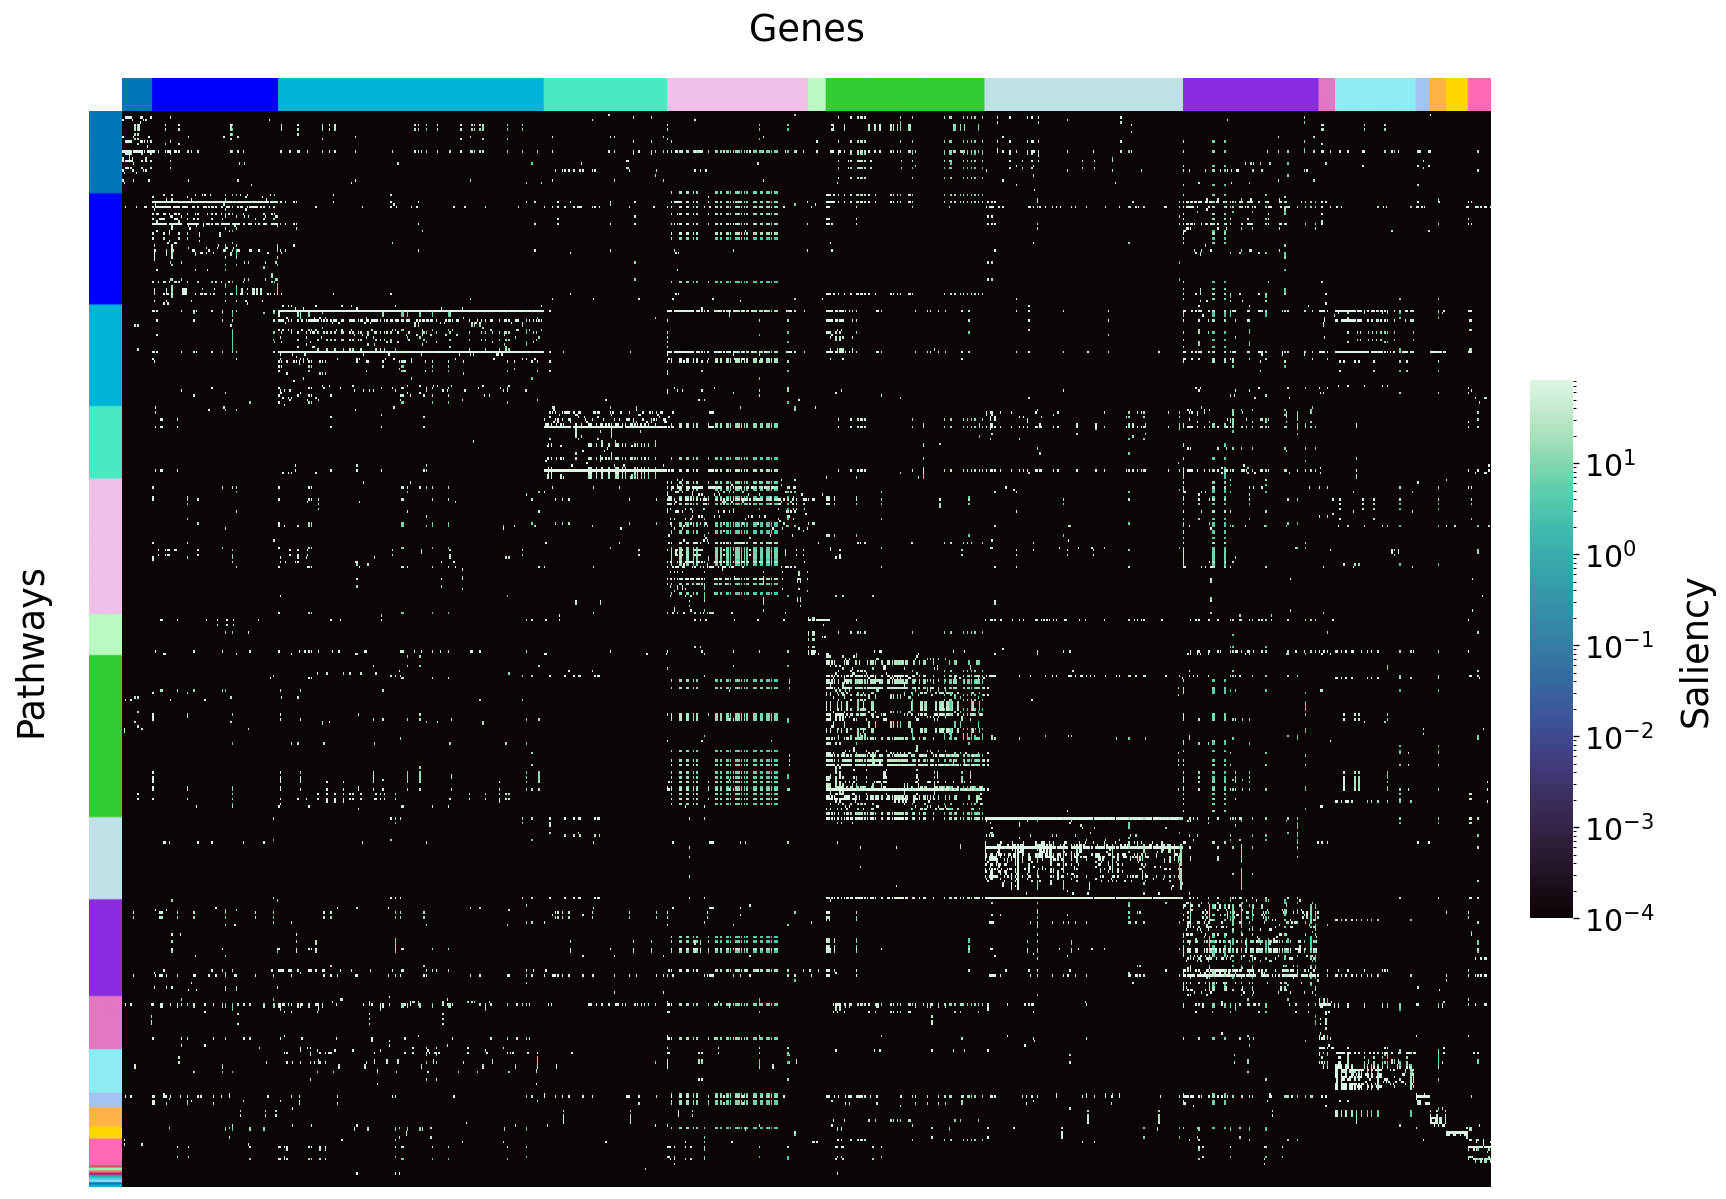

In [ ]:

import pandas as pd

# Stage 4/9 — Build pathway saliency and clusters
print('Stage 4/9 — Build pathway saliency and clusters')

df_enrich = pd.read_csv(
    "../gene_pathway_embedding/data/processed/gene_gene_pairs_with_pathwayA_enrichment_network.csv"
)

df_enrich = df_enrich[df_enrich["significance"] == "significant"]
df_enrich["enrich_score"] = -np.log10(df_enrich["pvalue"])
print('✓ Enrichment data loaded')

enrich_matrix, gene_names, pathway_names = load_or_build_enrichment_matrix(
    df_enrich,
    output_path
)
print('✓ Pathway enrichment matrix ready')

gene_to_idx = {g: i for i, g in enumerate(gene_names)}
pathway_to_idx = {p: i for i, p in enumerate(pathway_names)}

saliency_pathway_matrix = np.zeros(
    (len(pathway_names), len(gene_names))
)

# for g, gi in tqdm(
#     gene_to_idx.items(),
#     total=len(gene_to_idx),
#     desc="Gene–Pathway saliency"
# ):
#     saliency_pathway_matrix[:, gi] = (
#         saliency_np[gi] * enrich_matrix[gi]
#     )
for g, gi in tqdm(
    gene_to_idx.items(),
    total=len(gene_to_idx),
    desc="Gene–Pathway saliency"
):
    for p, pi in pathway_to_idx.items():
        saliency_pathway_matrix[pi, gi] = (
            saliency_np[gi] * enrich_matrix[gi, pi]
        )
np.save(
    os.path.join(output_path, "saliency_pathway_matrix.npy"),
    saliency_pathway_matrix
)
print('✓ Gene-pathway saliency matrix built')







bicluster = SpectralBiclustering(
    n_clusters=(10, 10),
    method="log",
    random_state=0
)

bicluster.fit(saliency_pathway_matrix)

row_labels = bicluster.row_labels_
col_labels = bicluster.column_labels_

save_top_gene_pathway_pairs(saliency_pathway_matrix, gene_names, pathway_names, output_path)
save_cluster_pathway_gene_flows(saliency_pathway_matrix, row_labels, gene_names, pathway_names, output_path)
print('✓ Top gene-pathway and cluster outputs saved')
gene_clusters = assign_gene_clusters(gene_names, col_labels)
gene_cluster_map = extract_gene_cluster_map(saliency_pathway_matrix, row_labels)

row_order = np.argsort(row_labels)
col_order = np.argsort(col_labels)

saliency_reordered = saliency_pathway_matrix[
    row_order, :
][:, col_order]

pathways_reordered = [pathway_names[i] for i in row_order]
genes_reordered = [gene_names[i] for i in col_order]

# Gene names from enrichment matrix
gene_names = sorted(df_enrich["Gene2"].unique())

# Assign gene → cluster from biclustering
gene_clusters = pd.Series(
    col_labels,
    index=gene_names
)

print('gene_clusters.value_counts()----from bicluster====', gene_clusters.value_counts())


pathway_clusters, gene_clusters, leiden_labels = leiden_bipartite_from_saliency(
    saliency_pathway_matrix,
    gene_names,
    pathway_names,
    resolution=1.2,
    weight_threshold=np.percentile(saliency_pathway_matrix, 75)
)

# Convert dict to pandas Series for consistent indexing
gene_clusters = pd.Series(gene_clusters, name="cluster")



# print('gene_clusters.value_counts()----from leidenclustering====', gene_clusters)

# ==========================================================
# Select TOP 1000 genes by total saliency (PLOT ONLY)
# ==========================================================

TOP_K_GENES = 1000

# Total gene saliency (sum across pathways)
gene_total_saliency = saliency_pathway_matrix.sum(axis=0)

# Top-1000 gene indices
top_gene_idx = np.argsort(gene_total_saliency)[::-1][:TOP_K_GENES]

# ---- Subset saliency matrix (pathways × genes)
saliency_pathway_matrix_top = saliency_pathway_matrix[:, top_gene_idx]

# ---- Subset gene names
gene_names_top = [gene_names[i] for i in top_gene_idx]

# ---- Subset gene clusters (Leiden)
gene_clusters_top = gene_clusters.loc[gene_names_top]

print(f"✔ Plotting top {len(gene_names_top)} genes (by saliency)")

leiden_heatmap_file = (
    f"leiden_gene_pathway_heatmap"
    f"_dim{args.dim_latent}"
    f"_lay{args.num_layers}"
    f"_hid{args.hidden_size}"
    f"_epo{args.epochs}.png"
)

plot_leiden_saliency_heatmap(
    saliency_pathway_matrix=saliency_pathway_matrix_top,
    gene_names=gene_names_top,
    pathway_names=pathway_names,          # pathways NOT subset
    gene_clusters=gene_clusters_top,
    pathway_clusters=pathway_clusters,    # unchanged
    output_path=output_path,
    args=args,
)



## 4.5 Stage 5 — Pathway-family mapping and explanation tables

In [19]:
# Stage 5/9 — Pathway families and explanation tables
print('Stage 5/9 — Pathway families and explanation tables')

PATHWAY_FAMILY_MAP = {
    "PI3K-AKT signaling pathway": "PI3K/AKT",
    "mTOR signaling pathway": "PI3K/AKT",
    "MAPK signaling pathway": "MAPK",
    "ERK cascade": "MAPK",
    "p53 signaling pathway": "Cell Cycle / DNA Damage",
    "Cell cycle": "Cell Cycle / DNA Damage",
    "DNA repair": "Cell Cycle / DNA Damage",
}

def map_to_family(p):
    return PATHWAY_FAMILY_MAP.get(p, "Other")    


def make_cluster_cmap_from_labels(cluster_ids):
    uniq = []
    for c in cluster_ids:
        if c not in uniq:
            uniq.append(c)
    palette = cc.glasbey[:len(uniq)]
    return dict(zip(uniq, palette))


# gene_cluster_ids = sorted(set(gene_clusters.values()))
gene_cluster_ids = sorted(gene_clusters.unique())

pathway_cluster_ids = sorted(set(pathway_clusters.values()))

gene_cmap = make_cluster_cmap_from_labels(gene_cluster_ids)
pathway_cmap = make_cluster_cmap_from_labels(pathway_cluster_ids)


expr_df = pd.read_csv(
    "../ACGNN_data/data/TCGA-BRCA.expression.tsv",
    sep="\t",
    index_col=0
)

expr_genes = set(expr_df.index)
gnn_genes = set(gene_names)
common_genes = sorted(expr_genes.intersection(gnn_genes))

expr_df = expr_df.loc[common_genes]

gene_to_expr_idx = {g: i for i, g in enumerate(common_genes)}

bicluster_gene_ids = genes_reordered
bicluster_pathway_ids = pathways_reordered
valid_genes = expr_df.index.intersection(bicluster_gene_ids)

expr_matrix = expr_df.loc[valid_genes].T.to_numpy()

np.save(
    os.path.join(output_path, "bicluster_row_labels.npy"),
    bicluster.row_labels_
)


########################################
# 12. GENE–PATHWAY EXPLANATION TABLE
########################################

rows = []
for p in range(saliency_pathway_matrix.shape[0]):
    top_genes = np.argsort(
        saliency_pathway_matrix[p]
    )[::-1][:20]

    for g in top_genes:
        rows.append([
            pathway_names[p],
            gene_names[g],
            saliency_pathway_matrix[p, g]
        ])




# -----------------------------------------
# Select ≤50 genes for gene-level Sankey
# -----------------------------------------

# MAX_GENES = 100

# # Total saliency per gene
# gene_scores = saliency_pathway_matrix.sum(axis=0)

# # Top genes by saliency
# top_gene_idx = np.argsort(gene_scores)[::-1][:MAX_GENES]

# selected_genes = [gene_names[i] for i in top_gene_idx]

# rows = []

# for g in selected_genes:
#     gi = gene_names.index(g)

#     for pi, pathway in enumerate(pathway_names):
#         score = saliency_pathway_matrix[pi, gi]
#         if score <= 0:
#             continue

#         rows.append({
#             "gene": g,
#             "pathway": pathway,
#             "weight": score,
#         })

# df = pd.DataFrame(rows)


print('✓ Leiden clustering complete')

# -------------------------------


Stage 5/9 — Pathway families and explanation tables
✓ Leiden clustering complete


## 4.6 Stage 6 — Patient expression and survival analysis

In [23]:

def preprocess_expression(expr_path, surv, gene_names):
    import pandas as pd

    # Load expression
    expr_df = pd.read_csv(
        expr_path,
        sep="\t",
        index_col=0
    )

    # sample → patient
    expr_df.columns = [c[:12] for c in expr_df.columns]

    # Align patients
    patient_ids = sorted(
        set(expr_df.columns).intersection(surv.index)
    )

    expr_df = expr_df[patient_ids]
    surv = surv.loc[patient_ids]

    # Align genes
    common_genes = sorted(set(expr_df.index).intersection(gene_names))
    expr_df = expr_df.loc[common_genes]

    gene_to_expr_idx = {g: i for i, g in enumerate(common_genes)}

    expr_matrix = expr_df.T.to_numpy()  # patients × genes

    return expr_matrix, expr_df, surv, patient_ids, common_genes, gene_to_expr_idx


def load_survival(path):
    import pandas as pd

    surv = pd.read_csv(path, sep="\t")
    if "_PATIENT" in surv.columns:
        surv = surv.rename(columns={"_PATIENT": "patient_id"})
    if "OS.time" in surv.columns:
        surv = surv.rename(columns={"OS.time": "time"})
    if "OS" in surv.columns:
        surv = surv.rename(columns={"OS": "event"})
    surv = surv.set_index("patient_id")[["time", "event"]]
    surv["time"] = surv["time"].astype(float)
    surv["event"] = surv["event"].astype(int)
    return surv


def km_pathway_family(df_surv, patient_family_scores, output_path):
    import os
    import matplotlib.pyplot as plt
    from lifelines import KaplanMeierFitter
    from lifelines.statistics import logrank_test

    km_dir = os.path.join(output_path, "KM_family")
    os.makedirs(km_dir, exist_ok=True)

    df_fam_surv = df_surv.copy()
    for f in patient_family_scores.columns:
        df_fam_surv[f"{f}_group"] = (df_fam_surv[f] >= df_fam_surv[f].median()).map({True: "High", False: "Low"})

    def plot_km_family(df, family):
        kmf = KaplanMeierFitter()
        plt.figure(figsize=(5, 4))
        for grp in ["High", "Low"]:
            mask = df[f"{family}_group"] == grp
            kmf.fit(df.loc[mask, "time"], df.loc[mask, "event"], label=f"{family} {grp}")
            kmf.plot_survival_function(ci_show=False)
        g1 = df[f"{family}_group"] == "High"
        g2 = df[f"{family}_group"] == "Low"
        res = logrank_test(df.loc[g1, "time"], df.loc[g2, "time"], df.loc[g1, "event"], df.loc[g2, "event"])
        plt.title(f"{family}\nLog-rank p = {res.p_value:.2e}")
        plt.xlabel("Days")
        plt.ylabel("Overall Survival")
        plt.tight_layout()
        plt.savefig(os.path.join(km_dir, f"KM_{family}.pdf"))
        plt.show()

    for fam in patient_family_scores.columns:
        plot_km_family(df_fam_surv, fam)


def gene_pathway_heatmaps(saliency_pathway_matrix, gene_names, pathway_names, patient_cluster_scores, row_labels, col_labels, output_path):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import os

    df_heat = pd.DataFrame(saliency_pathway_matrix, index=pathway_names, columns=gene_names)
    os.makedirs(output_path, exist_ok=True)

    # Dendrogram + heatmap
    sns.clustermap(df_heat, cmap="Reds", metric="cosine", method="average", figsize=(10, 8), linewidths=0.1)
    plt.savefig(os.path.join(output_path, "gene_pathway_dendrogram_heatmap.pdf"))
    plt.show()

    sns.clustermap(
        df_heat,
        cmap="vlag",
        center=0,
        metric="cosine",
        method="average",
        z_score=1,
        figsize=(11, 9),
        dendrogram_ratio=(0.15, 0.15),
        cbar_kws={"label": "Saliency × Enrichment"}
    )
    plt.savefig(os.path.join(output_path, "gene_pathway_dendrogram_heatmap.png"), dpi=300)
    plt.show()

    sns.clustermap(
        patient_cluster_scores,
        cmap="vlag",
        metric="correlation",
        z_score=1,
        figsize=(8, 10),
        col_cluster=False
    )
    plt.savefig(os.path.join(output_path, "patient_cluster_dendrogram.pdf"))
    plt.show()

    df_reordered = df_heat.iloc[np.argsort(row_labels), np.argsort(col_labels)]
    sns.heatmap(df_reordered, cmap="Reds", yticklabels=True, xticklabels=True)
    plt.title("Spectral Biclustering Heatmap")
    plt.savefig(os.path.join(output_path, "bicluster_heatmap.pdf"))
    plt.show()


def plot_gene_pathway_modules(df_enrich, output_path):
    os.makedirs(output_path, exist_ok=True)
    build_and_plot_gene_pathway_modules(
        df_enrich=df_enrich,
        output_path=os.path.join(output_path, "gene_pathway_modules"),
        top_genes=30,
        top_pathways=25
    )

    build_and_plot_gene_pathway_umap(
        df_enrich=df_enrich,
        output_path=os.path.join(output_path, "gene_pathway_umap"),
        top_genes=40,
        top_pathways=40
    )

    # plot_pathway_enrichment_dotplot(df_enrich=df_enrich, output_path=output_path, top_k=10)


def cox_pathway_family(patient_family_scores, df_family_surv, output_path):
    import os
    import numpy as np
    import pandas as pd
    from lifelines import CoxPHFitter
    from statsmodels.stats.multitest import multipletests
    import matplotlib.pyplot as plt

    os.makedirs(output_path, exist_ok=True)

    cox_results = []
    for fam in patient_family_scores.columns:
        df_tmp = df_family_surv[["time", "event", fam]].dropna()
        if df_tmp[fam].std() == 0:
            continue
        cph = CoxPHFitter()
        cph.fit(df_tmp, duration_col="time", event_col="event")
        s = cph.summary.loc[fam]
        cox_results.append({
            "Family": fam,
            "HR": s["exp(coef)"],
            "CI_lower": s["exp(coef) lower 95%"],
            "CI_upper": s["exp(coef) upper 95%"],
            "p": s["p"]
        })

    df_cox_family = pd.DataFrame(cox_results)
    df_cox_family["FDR"] = multipletests(df_cox_family["p"], method="fdr_bh")[1]
    df_cox_family = df_cox_family.sort_values("p")
    df_cox_family.to_csv(os.path.join(output_path, "cox_pathway_families.csv"), index=False)

    df_plot = df_cox_family.copy()
    plt.figure(figsize=(6, 0.5 * len(df_plot)))
    y = np.arange(len(df_plot))
    plt.errorbar(
        df_plot["HR"],
        y,
        xerr=[df_plot["HR"] - df_plot["CI_lower"], df_plot["CI_upper"] - df_plot["HR"]],
        fmt="o",
        color="black",
        ecolor="black",
        capsize=3
    )
    plt.axvline(1, linestyle="--", color="red")
    plt.yticks(y, df_plot["Family"])
    plt.xlabel("Hazard Ratio")
    plt.title("Pathway-Family Cox Regression")
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, "cox_pathway_family_forest.pdf"))
    plt.show()


def map_genes_to_clusters(saliency_pathway_matrix, bicluster, top_k=20):
    from collections import defaultdict
    import numpy as np

    gene_cluster_map = defaultdict(list)

    for p_idx, cluster_id in enumerate(bicluster.row_labels_):
        gene_scores = saliency_pathway_matrix[p_idx]
        top_genes = np.argsort(gene_scores)[::-1][:top_k]
        gene_cluster_map[cluster_id].extend(top_genes)

    # Deduplicate
    for c in gene_cluster_map:
        gene_cluster_map[c] = list(set(gene_cluster_map[c]))

    return gene_cluster_map


def plot_cluster_sankey(df_cluster, cluster_name, output_path, cluster_colors=None, pathway_family_map=None):

    os.makedirs(output_path, exist_ok=True)

    if pathway_family_map is None:
        pathway_family_map = {}

    # Map pathways to families
    df_cluster["PathwayFamily"] = df_cluster["Pathway"].apply(lambda x: pathway_family_map.get(x, "Other"))

    families = sorted(df_cluster["PathwayFamily"].unique())
    pathways = sorted(df_cluster["Pathway"].unique())
    genes = sorted(df_cluster["Gene"].unique())
    labels = [cluster_name] + families + pathways + genes
    label_to_id = {l: i for i, l in enumerate(labels)}

    source, target, value = [], [], []

    # Cluster → Family
    cf = df_cluster.groupby("PathwayFamily")["Value"].sum().reset_index()
    for _, r in cf.iterrows():
        source.append(label_to_id[cluster_name])
        target.append(label_to_id[r["PathwayFamily"]])
        value.append(r["Value"])

    # Family → Pathway
    fp = df_cluster.groupby(["PathwayFamily", "Pathway"])["Value"].sum().reset_index()
    for _, r in fp.iterrows():
        source.append(label_to_id[r["PathwayFamily"]])
        target.append(label_to_id[r["Pathway"]])
        value.append(r["Value"])

    # Pathway → Gene
    pg = df_cluster.groupby(["Pathway", "Gene"])["Value"].sum().reset_index()
    for _, r in pg.iterrows():
        source.append(label_to_id[r["Pathway"]])
        target.append(label_to_id[r["Gene"]])
        value.append(r["Value"])

    # Node colors
    if cluster_colors is None:
        cluster_colors = {cluster_name: "#0077B6"}
    node_colors = [
        cluster_colors.get(lbl, "#ADB5BD" if lbl in families else "#CED4DA" if lbl in pathways else "#E9ECEF")
        for lbl in labels
    ]

    fig = go.Figure(
        go.Sankey(
            arrangement="snap",
            node=dict(label=labels, color=node_colors, pad=15, thickness=14, line=dict(color="black", width=0.3)),
            link=dict(source=source, target=target, value=value)
        )
    )

    fig.update_layout(title=f"{cluster_name}: Pathway–Gene Attribution", font=dict(size=11, family="Times New Roman"), width=1100, height=750)
    fig.write_image(os.path.join(output_path, f"sankey_{cluster_name}.svg"), scale=2)
    fig.write_image(os.path.join(output_path, f"sankey_{cluster_name}.pdf"), scale=2)


from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import os
import pandas as pd

def plot_km_clusters(df_surv, patient_cluster_scores, output_path):
    """
    Plots Kaplan–Meier curves for each cluster based on median stratification,
    saves SVG and PDF, and outputs log-rank p-values.

    Parameters
    ----------
    df_surv : pd.DataFrame
        Survival DataFrame with columns ["time", "event"] indexed by patient.
    patient_cluster_scores : pd.DataFrame
        Patient × cluster score matrix (values to stratify patients).
    output_path : str
        Directory to save KM plots and p-values CSV.
    """
    km_dir = os.path.join(output_path, "survival")
    os.makedirs(km_dir, exist_ok=True)

    # Store log-rank p-values
    results = []

    for cluster_id in patient_cluster_scores.columns:
        df = df_surv.copy()
        median_score = df[cluster_id].median()
        df["group"] = df[cluster_id] >= median_score

        # KM curves
        kmf_high = KaplanMeierFitter()
        kmf_low = KaplanMeierFitter()

        plt.figure(figsize=(5, 4))
        kmf_high.fit(
            df[df["group"]]["time"],
            df[df["group"]]["event"],
            label="High activity"
        )
        kmf_low.fit(
            df[~df["group"]]["time"],
            df[~df["group"]]["event"],
            label="Low activity"
        )
        kmf_high.plot(ci_show=False)
        kmf_low.plot(ci_show=False)

        # Log-rank test
        result = logrank_test(
            df[df["group"]]["time"],
            df[~df["group"]]["time"],
            df[df["group"]]["event"],
            df[~df["group"]]["event"]
        )

        # Title with p-value
        plt.title(f"Cluster {cluster_id} Survival\nlog-rank p = {result.p_value:.3e}")
        plt.xlabel("Time (days)")
        plt.ylabel("Survival probability")
        plt.tight_layout()

        # Save plots
        for fmt in ["svg", "pdf"]:
            plt.savefig(os.path.join(km_dir, f"cluster_{cluster_id}_survival.{fmt}"))
        plt.show()

        # Save log-rank p-value
        results.append([cluster_id, result.p_value])

    # Save all p-values
    pd.DataFrame(results, columns=["Cluster", "LogRank_p"]).to_csv(
        os.path.join(km_dir, "cluster_survival_pvalues.csv"),
        index=False
    )
    print(f"✅ KM plots and log-rank p-values saved in {km_dir}")


def plot_joint_gene_pathway_umap(
    enrich_matrix,
    pathway_saliency,
    gene_names,
    pathway_names,
    output_path
):
    import umap
    import numpy as np
    import matplotlib.pyplot as plt
    import os

    n_genes, n_pathways = enrich_matrix.shape

    if len(pathway_saliency) != n_pathways:
        raise ValueError("pathway_saliency length must match number of pathways")

    gene_features = enrich_matrix

    pathway_features = np.zeros((n_pathways, n_pathways))
    np.fill_diagonal(pathway_features, pathway_saliency)

    X = np.vstack([gene_features, pathway_features])

    labels = (
        ["Gene"] * n_genes +
        ["Pathway"] * n_pathways
    )

    names = gene_names + pathway_names

    umap_model = umap.UMAP(
        n_neighbors=20,
        min_dist=0.2,
        n_components=2,
        random_state=42
    )

    X_umap = umap_model.fit_transform(X)

    plt.figure(figsize=(6, 5))

    gene_mask = np.array(labels) == "Gene"
    path_mask = np.array(labels) == "Pathway"

    plt.scatter(
        X_umap[gene_mask, 0],
        X_umap[gene_mask, 1],
        s=12,
        alpha=0.6,
        label="Genes"
    )

    plt.scatter(
        X_umap[path_mask, 0],
        X_umap[path_mask, 1],
        s=60,
        marker="^",
        alpha=0.9,
        label="Pathways"
    )

    plt.legend(frameon=False)
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.title("Joint Gene–Pathway UMAP")

    
    plt.tight_layout()
    plt.savefig(
        os.path.join(output_path, "UMAP_gene_pathway_joint.pdf")
    )
    plt.show()

def compute_patient_cluster_scores(
    saliency_pathway_matrix,
    row_labels,
    gene_names,
    gene_to_expr_idx,
    expr_matrix,
    patient_ids=None,
    top_k=50,
    agg="mean",
    min_genes=1,
    return_metadata=False,
):
    """
    Robust computation of per-patient cluster expression scores.
    Safe against patient filtering, missing genes, and index mismatch.
    """

    # --------------------------------------------------
    # 0. Input sanity (soft)
    # --------------------------------------------------
    if patient_ids is not None and len(patient_ids) != expr_matrix.shape[0]:
        warnings.warn(
            f"[compute_patient_cluster_scores] "
            f"patient_ids length ({len(patient_ids)}) != "
            f"expr_matrix rows ({expr_matrix.shape[0]}). "
            f"Falling back to positional index."
        )
        patient_ids = None  # fallback safely

    # --------------------------------------------------
    # 1. Collect expression indices per cluster
    # --------------------------------------------------
    cluster_to_expr_idxs = defaultdict(set)

    for pathway_idx, cluster_id in enumerate(row_labels):
        top_gene_idxs = np.argsort(
            saliency_pathway_matrix[pathway_idx]
        )[::-1][:top_k]

        for g_idx in top_gene_idxs:
            gene = gene_names[g_idx]
            if gene in gene_to_expr_idx:
                expr_idx = gene_to_expr_idx[gene]
                # extra guard against corrupted mappings
                if expr_idx < expr_matrix.shape[1]:
                    cluster_to_expr_idxs[cluster_id].add(expr_idx)

    # --------------------------------------------------
    # 2. Aggregate per-patient scores
    # --------------------------------------------------
    scores = {}
    meta = []

    for cluster_id, expr_idxs in cluster_to_expr_idxs.items():
        if len(expr_idxs) < min_genes:
            continue

        submat = expr_matrix[:, sorted(expr_idxs)]

        if agg == "mean":
            vals = submat.mean(axis=1)
        elif agg == "median":
            vals = np.median(submat, axis=1)
        else:
            raise ValueError(f"Unsupported aggregation: {agg}")

        scores[f"Cluster_{cluster_id}"] = vals
        meta.append({
            "cluster": f"Cluster_{cluster_id}",
            "n_genes": len(expr_idxs),
        })

    # --------------------------------------------------
    # 3. Build DataFrame
    # --------------------------------------------------
    scores_df = pd.DataFrame(
        scores,
        index=patient_ids if patient_ids is not None else None,
    )

    if return_metadata:
        meta_df = pd.DataFrame(meta).set_index("cluster")
        return scores_df, meta_df

    return scores_df



def run_km_by_clusters(
    df_surv,
    output_path,
    time_col="time",
    event_col="event",
    cluster_prefix="Cluster_",
    min_samples=20,
    figsize=(5.5, 4.5),
):
    """
    Kaplan–Meier + Log-rank + Cox HR (95% CI) per cluster.

    Returns
    -------
    results_df : pd.DataFrame
        cluster | p_value | HR | HR_low | HR_high | n_high | n_low
    """

    plt.rcParams.update({
        "font.size": 18,
        "axes.titlesize": 24,
        "axes.labelsize": 24,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 18,
    })

    os.makedirs(output_path, exist_ok=True)

    cluster_cols = [c for c in df_surv.columns if c.startswith(cluster_prefix)]
    if len(cluster_cols) == 0:
        raise ValueError(f"No columns with prefix '{cluster_prefix}'")

    results = []

    for col in cluster_cols:
        df = df_surv[[time_col, event_col, col]].dropna()

        if df.shape[0] < min_samples:
            continue

        # ------------------------------
        # Median stratification
        # ------------------------------
        median_val = df[col].median()
        df["group"] = np.where(df[col] >= median_val, "High", "Low")

        df_high = df[df["group"] == "High"]
        df_low  = df[df["group"] == "Low"]

        if len(df_high) < 5 or len(df_low) < 5:
            continue

        # ------------------------------
        # Log-rank test
        # ------------------------------
        lr = logrank_test(
            df_high[time_col],
            df_low[time_col],
            event_observed_A=df_high[event_col],
            event_observed_B=df_low[event_col],
        )
        pval = lr.p_value

        # ------------------------------
        # Cox PH for HR + CI
        # ------------------------------
        df_cox = df[[time_col, event_col, "group"]].copy()
        df_cox["group"] = (df_cox["group"] == "High").astype(int)

        cph = CoxPHFitter()
        cph.fit(
            df_cox,
            duration_col=time_col,
            event_col=event_col,
            show_progress=False,
        )

        hr = np.exp(cph.params_["group"])
        ci = np.exp(cph.confidence_intervals_.loc["group"])
        hr_low, hr_high = ci.iloc[0], ci.iloc[1]

        # ------------------------------
        # KM plot
        # ------------------------------
        fig, ax = plt.subplots(figsize=figsize)
        kmf = KaplanMeierFitter()

        kmf.fit(
            df_high[time_col],
            event_observed=df_high[event_col],
            label=f"High (n={len(df_high)})",
        )
        kmf.plot(ax=ax, ci_show=True, ci_alpha=0.18, linewidth=2)

        kmf.fit(
            df_low[time_col],
            event_observed=df_low[event_col],
            label=f"Low (n={len(df_low)})",
        )
        kmf.plot(ax=ax, ci_show=True, ci_alpha=0.18, linewidth=2)


        ax.set_xlabel("")
        ax.set_ylabel("")
        # ax.set_xlabel("Time")
        # ax.set_ylabel("Survival probability")
        ax.set_title(col, fontsize=24)
        ax.grid(False)

        # ------------------------------
        # In-plot annotation (BOTTOM-LEFT)
        # ------------------------------
        ax.text(
            0.02, 0.02,
            (
                rf"$\log_{{10}}(p)$ = {np.log10(pval):.2f}" "\n"
                rf"HR = {hr:.2f} [{hr_low:.2f}–{hr_high:.2f}]"
            ),
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=18,
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="white",
                alpha=0.85,
                edgecolor="none",
            ),
        )

        plt.tight_layout()
        plt.savefig(
            os.path.join(output_path, f"KM_{col}.png"),
            dpi=300,
        )
        plt.show()

        # ------------------------------
        # Store results
        # ------------------------------
        results.append({
            "cluster": col,
            "p_value": pval,
            "log10_p": np.log10(pval),
            "HR": hr,
            "HR_low": hr_low,
            "HR_high": hr_high,
            "n_high": len(df_high),
            "n_low": len(df_low),
            "n_total": df.shape[0],
        })

    return (
        pd.DataFrame(results)
        .sort_values("p_value")
        .reset_index(drop=True)
    )


def get_pvalue_column(df):
    for c in [
        "p_value", "p.adjust", "pvalue",
        "P-value", "FDR", "q_value"
    ]:
        if c in df.columns:
            return c
    raise ValueError(
        f"No p-value column found. Available columns: {df.columns.tolist()}"
    )

def add_high_low_groups(df_surv):
    for c in df_surv.columns.drop(["time", "event"]):
        df_surv[f"{c}_group"] = (
            df_surv[c] >= df_surv[c].median()
        ).map({True: "High", False: "Low"})
    return df_surv

def plot_patient_cluster_heatmap(
    patient_cluster_scores,
    surv,
    output_path
):
    import os
    import seaborn as sns
    import matplotlib.pyplot as plt

    ordered = (
        patient_cluster_scores
        .mean(axis=1)
        .sort_values(ascending=False)
        .index
    )

    X = patient_cluster_scores.loc[ordered]
    X = (X - X.mean()) / X.std()

    plt.figure(figsize=(9, 7))
    sns.heatmap(
        X,
        cmap="vlag",
        center=0,
        yticklabels=False,
        cbar_kws={"label": "Z-score"}
    )
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            output_path,
            "heatmap_patient_cluster_bicluster_aligned.pdf"
        )
    )
    plt.show()

def evaluate_survival(df_surv, output_path):

    y = Surv.from_arrays(
        event=df_surv["event"].astype(bool).values,
        time=df_surv["time"].values
    )

    for c in df_surv.columns.drop(["time", "event"]):
        risk = df_surv[c].values

        ci_ipcw = concordance_index_ipcw(y, y, -risk)[0]
        ci_h = concordance_index(df_surv["time"], -risk, df_surv["event"])

        times = np.linspace(
            df_surv["time"].quantile(0.05),
            df_surv["time"].quantile(0.95),
            10
        )

        auc, mean_auc = cumulative_dynamic_auc(y, y, -risk, times)

        plt.figure(figsize=(5, 4))
        plt.plot(times / 365.0, auc, marker="o")
        plt.tight_layout()
        plt.savefig(
            os.path.join(output_path, f"ROC_time_{c}.pdf")
        )
        plt.show()

        print(
            f"{c} | IPCW: {ci_ipcw:.3f} | "
            f"Harrell: {ci_h:.3f} | AUC: {mean_auc:.3f}"
        )



def plot_global_km(
    df_surv,
    output_path=None,
    time_col="time",
    event_col="event",
    figsize=(5.5, 4.5),
):
    """
    Plot global Kaplan–Meier curve for all patients
    using the SAME visual style as cluster KM plots.

    Parameters
    ----------
    df_surv : pd.DataFrame
        Survival dataframe
    output_path : str or None
        Directory to save the plot
    time_col : str
        Survival time column
    event_col : str
        Event indicator column (1=event, 0=censored)
    figsize : tuple
        Figure size
    """

    # ------------------------------------
    # Validate columns
    # ------------------------------------
    for col in [time_col, event_col]:
        if col not in df_surv.columns:
            raise KeyError(
                f"Column '{col}' not found in df_surv. "
                f"Available columns: {list(df_surv.columns)}"
            )

    # ------------------------------------
    # Prepare data
    # ------------------------------------
    df = df_surv.copy()
    df["time"] = pd.to_numeric(df[time_col], errors="coerce")
    df["event"] = pd.to_numeric(df[event_col], errors="coerce")
    df = df.dropna(subset=["time", "event"])

    if df.shape[0] < 20:
        raise ValueError("Too few samples for global KM")

    # ------------------------------------
    # Fit KM
    # ------------------------------------
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=df["time"],
        event_observed=df["event"],
        label=f"All patients (n={df.shape[0]})",
    )

    # ------------------------------------
    # Plot
    # ------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    kmf.plot(
        ax=ax,
        ci_show=True,
        ci_alpha=0.18,
        linewidth=2,
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("Survival probability")
    ax.set_title("Global Kaplan–Meier Curve", fontsize=14)
    ax.grid(False)

    # ------------------------------------
    # Median survival annotation
    # ------------------------------------
    median_surv = kmf.median_survival_time_

    if np.isfinite(median_surv):
        median_text = f"Median survival = {median_surv:.1f}"
    else:
        median_text = "Median survival not reached"

    # ------------------------------------
    # In-plot annotation (same style)
    # ------------------------------------
    ax.text(
        0.02,
        0.02,
        median_text,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=10.5,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            alpha=0.85,
            edgecolor="none",
        ),
    )

    plt.tight_layout()

    # ------------------------------------
    # Save
    # ------------------------------------
    if output_path is not None:
        os.makedirs(output_path, exist_ok=True)
        plt.savefig(
            os.path.join(output_path, "KM_global.png"),
            dpi=300,
        )

    plt.show()



Stage 6/9 — Expression and survival analysis
✅ Aligned patients: 1073
✅ Survival × cluster table: (1229, 12)
✅ df_surv is ready for Cox / C-index / time-dependent AUC
patient_cluster_scores=========               Cluster_0  Cluster_3  Cluster_9  Cluster_8  Cluster_7  \
TCGA-3C-AAAU   4.104036   4.182760   4.347891   4.229317   4.730768   
TCGA-3C-AALI   4.026066   4.172911   4.239990   4.169216   4.792402   
TCGA-3C-AALJ   3.878367   4.041696   4.075890   4.015017   4.523827   
TCGA-3C-AALK   3.972881   4.163826   4.155756   4.100209   4.704227   
TCGA-4H-AAAK   4.178183   4.308863   4.387971   4.321844   4.892421   
...                 ...        ...        ...        ...        ...   
TCGA-WT-AB44   3.887103   3.959967   4.114930   3.993242   4.653018   
TCGA-XX-A899   3.801288   3.978136   4.032634   3.913860   4.480261   
TCGA-XX-A89A   4.063382   4.124698   4.271551   4.183722   4.805545   
TCGA-Z7-A8R5   4.154858   4.507157   4.384152   4.313050   4.946992   
TCGA-Z7-A8R6   3.807

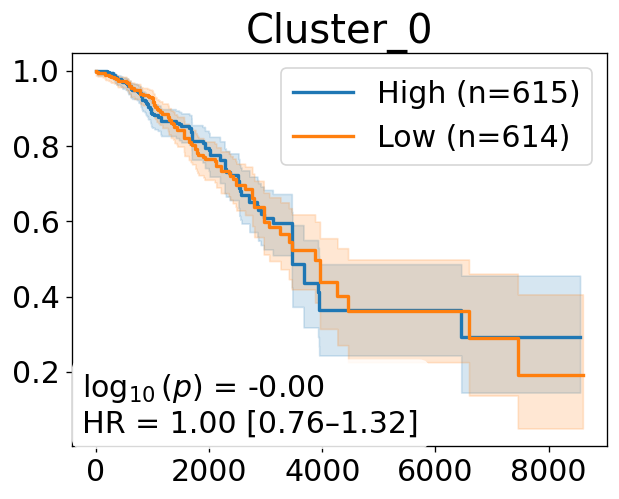

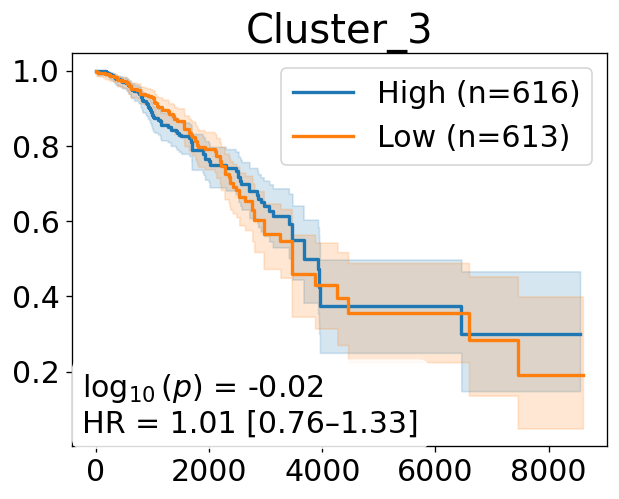

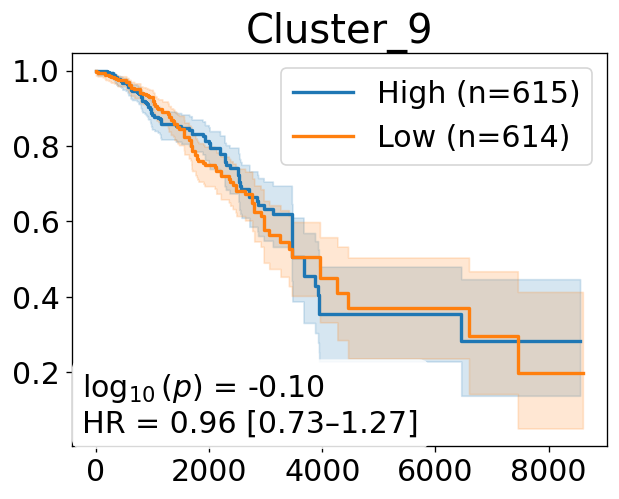

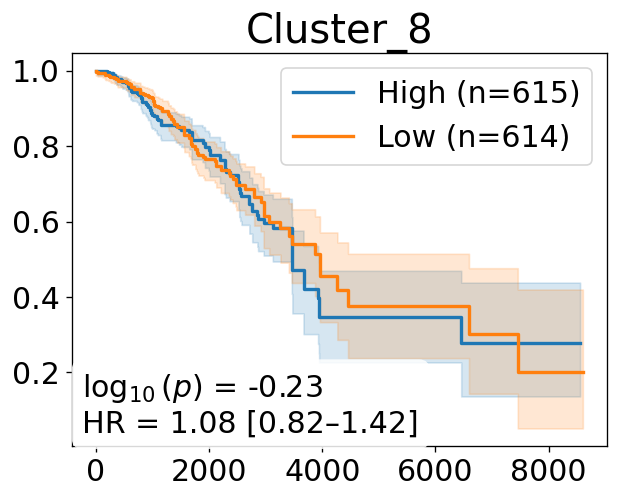

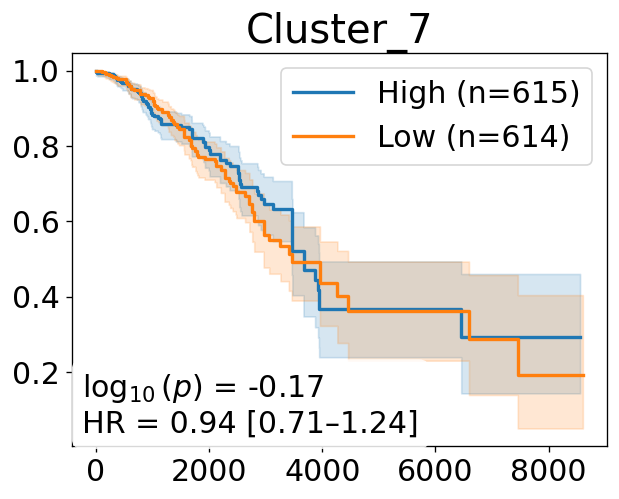

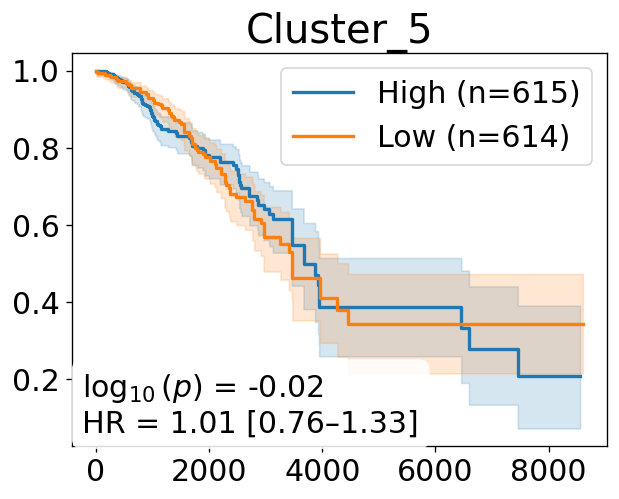

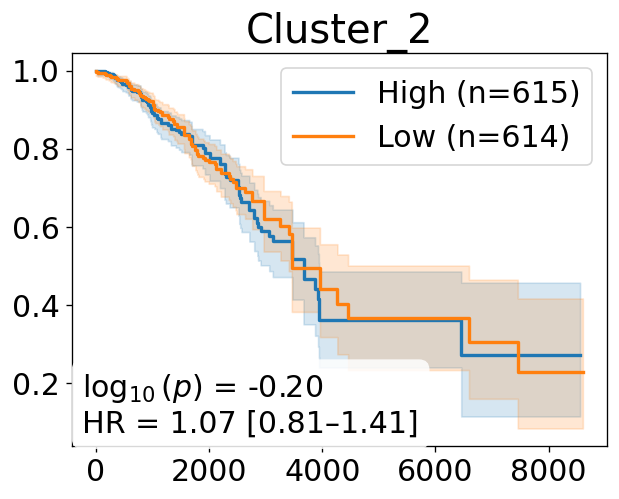

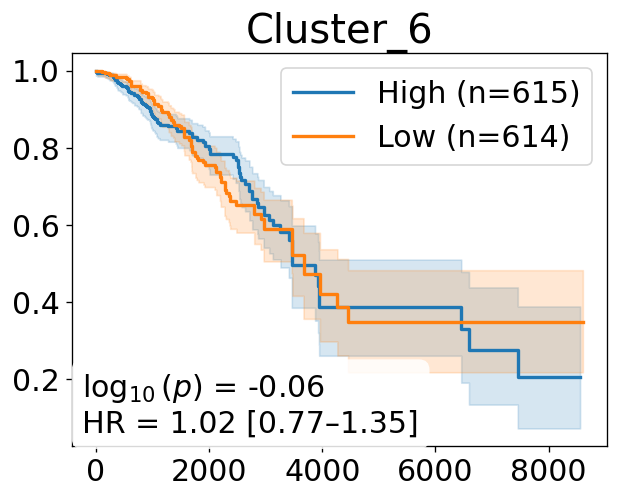

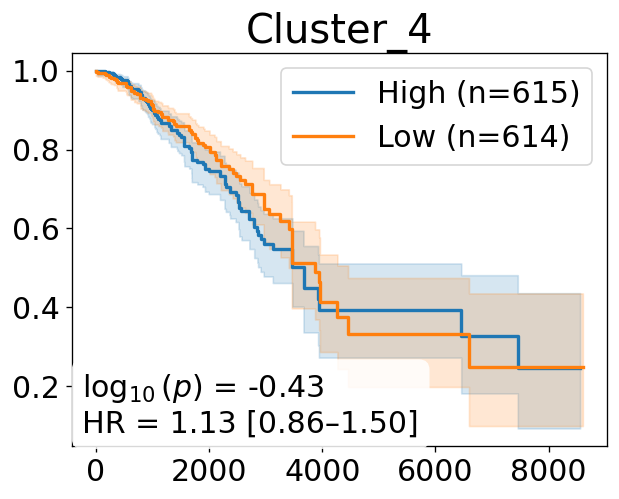

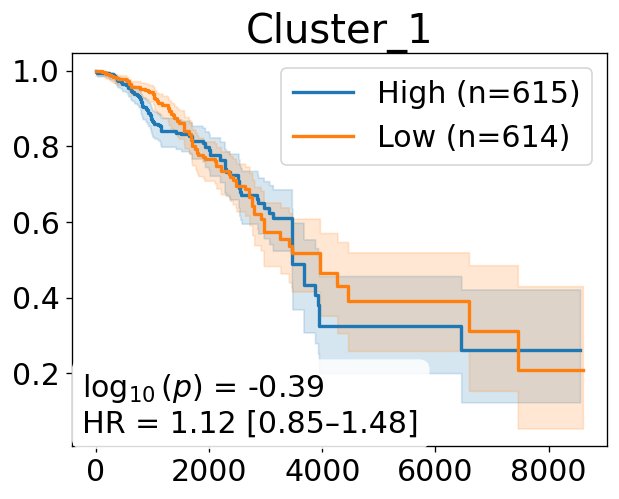

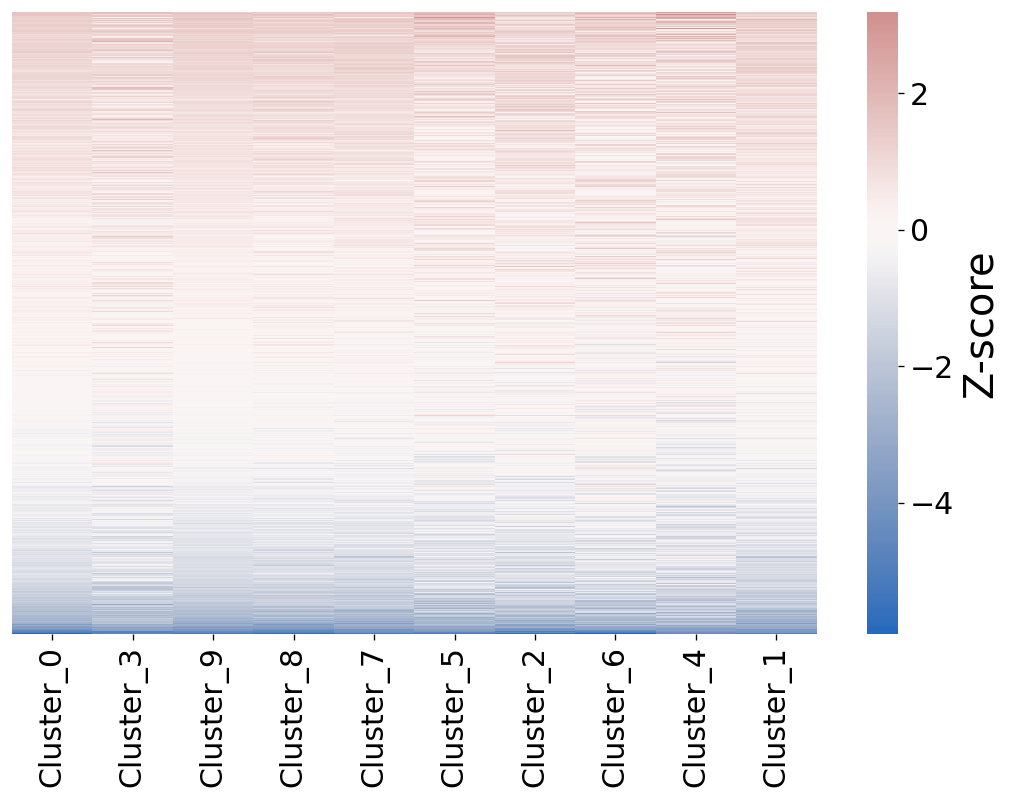

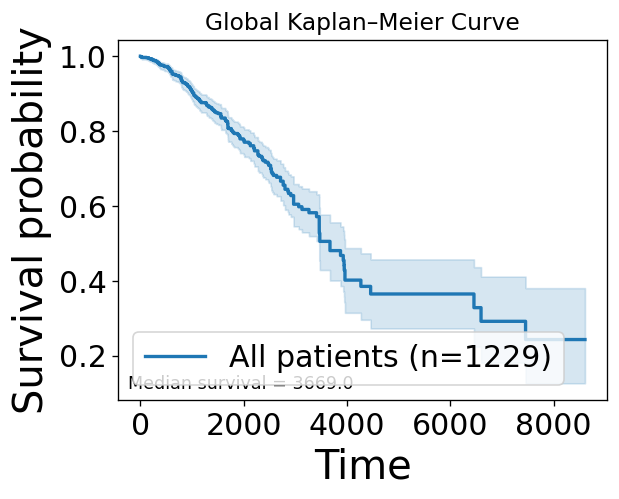

In [ ]:
# Stage 6/9 — Expression and survival analysis
print('Stage 6/9 — Expression and survival analysis')

# 7. Expression & survival analysis
# -------------------------------
surv = load_survival("../ACGNN_data/data/TCGA-BRCA.survival.tsv")
expr_matrix, expr_df, surv, patient_ids, common_genes, gene_to_expr_idx = \
preprocess_expression(
    "../ACGNN_data/data/TCGA-BRCA.expression.tsv",
    surv,
    gene_names
)

# --- HARD ALIGN patients ---
expr_patients = np.array(patient_ids)
surv_patients = set(surv.index)

keep = [i for i, p in enumerate(expr_patients) if p in surv_patients]

expr_matrix = expr_matrix[keep, :]
patient_ids = expr_patients[keep].tolist()

print(f"✅ Aligned patients: {len(patient_ids)}")


surv_df = surv.copy()

patient_cluster_scores, cluster_stats = compute_patient_cluster_scores(
    saliency_pathway_matrix=saliency_pathway_matrix,
    row_labels=row_labels,
    gene_names=gene_names,
    gene_to_expr_idx=gene_to_expr_idx,
    expr_matrix=expr_matrix,
    patient_ids=patient_ids,
    top_k=50,
    min_genes=5,
    return_metadata=True,
)

df_surv = surv_df.join(patient_cluster_scores, how="inner")

print(f"✅ Survival × cluster table: {df_surv.shape}")
cluster_cols = [c for c in df_surv.columns if c.startswith("Cluster_")]

assert df_surv.shape[0] > 0, "No overlapping patients after join"
assert df_surv[cluster_cols].isna().sum().sum() == 0, "NaNs in cluster scores"

# Rename for downstream survival libraries (optional)
df_surv = df_surv.rename(
    columns={
        "OS.time": "time",
        "OS": "event",
    }
)

print("✅ df_surv is ready for Cox / C-index / time-dependent AUC")

print('patient_cluster_scores=========', patient_cluster_scores)


km_results = run_km_by_clusters(
    df_surv=df_surv,
    output_path=output_path,
)



    
df_surv = surv.join(patient_cluster_scores, how="inner")

# evaluate_survival(df_surv, output_path)
plot_patient_cluster_heatmap(patient_cluster_scores, surv, output_path)
df_surv = add_high_low_groups(df_surv)

plot_global_km(
    df_surv,
    output_path=output_path,
    time_col="time",
    event_col="event",
)


In [26]:

def compute_global_score(df_surv):
    """
    Compute global pathway activity score by summing all cluster scores.
    Assumes cluster columns start with 'Cluster' and do NOT end with '_group'.
    """
    cluster_cols = [
        c for c in df_surv.columns
        if c.startswith("Cluster") and not c.endswith("_group")
    ]
    df_surv["GlobalScore"] = df_surv[cluster_cols].sum(axis=1)

    # Median-based High/Low group
    df_surv["Global_group"] = (df_surv["GlobalScore"] >= df_surv["GlobalScore"].median()) \
                                .map({True: "High", False: "Low"})
    return df_surv

def add_high_low_survival(df_surv, score_col):
    """
    Adds 'survival_group' column with values {'High','Low'}
    """
    df_surv = df_surv.copy()
    median_val = df_surv[score_col].median()
    df_surv["survival_group"] = np.where(
        df_surv[score_col] >= median_val,
        "High",
        "Low"
    )
    return df_surv

#############################################
# 2. GENE-LEVEL SALIENCY PER SURVIVAL GROUP
#############################################

def compute_group_gene_saliency(
    model,
    graph,
    features,
    node_to_patient,
    df_surv,
    group_name,
    cache_dir,
):
    """
    Computes gene-level saliency for a survival group.
    """

    os.makedirs(cache_dir, exist_ok=True)

    # Patients in group
    patients = set(
        df_surv.loc[
            df_surv["survival_group"] == group_name,
            "patient_id"
        ]
    )

    # Node mask
    node_mask = np.array([
        pid in patients for pid in node_to_patient
    ])

    relevance = load_or_compute_relevance(
        model=model,
        graph=graph,
        features=features,
        method="saliency",
        node_mask=node_mask,
        cache_dir=os.path.join(cache_dir, group_name),
        force_recompute=False,
    )

    # Collapse feature → gene
    gene_saliency = relevance.sum(dim=1)
    return gene_saliency.detach().cpu().numpy()

#############################################
# 3. PROJECT GENE SALIENCY → PATHWAY SPACE
#############################################

def build_saliency_pathway_matrix(
    gene_saliency,
    enrich_matrix,
):
    """
    enrich_matrix: shape [genes × pathways]
    returns: [pathways × genes]
    """
    n_genes, n_pathways = enrich_matrix.shape
    mat = np.zeros((n_pathways, n_genes))

    for gi in range(n_genes):
        mat[:, gi] = gene_saliency[gi] * enrich_matrix[gi]

    return mat

#############################################
# 4. DIFFERENTIAL HEATMAP (High − Low)
#############################################

def plot_survival_difference_heatmap(
    diff_matrix,
    gene_names,
    pathway_names,
    gene_clusters,
    pathway_clusters,
    output_path,
    filename="saliency_high_minus_low.png",
    vmax_percentile=99,
    figsize=(16, 12),
):
    os.makedirs(output_path, exist_ok=True)

    vmax = np.percentile(np.abs(diff_matrix), vmax_percentile)

    plt.figure(figsize=figsize)
    sns.heatmap(
        diff_matrix,
        cmap="RdBu_r",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        xticklabels=False,
        yticklabels=False,
        rasterized=True,
    )

    plt.title("High − Low Survival Saliency", fontsize=20)
    plt.xlabel("Genes")
    plt.ylabel("Pathways")

    plt.tight_layout()
    plt.savefig(
        os.path.join(output_path, filename),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

#############################################
# 5. FULL DRIVER FUNCTION
#############################################

def run_survival_stratified_saliency(
    model,
    G_dgl,
    node_to_patient,
    df_surv,
    risk_score_col,
    enrich_matrix,
    gene_names,
    pathway_names,
    gene_clusters,
    pathway_clusters,
    output_path,
):
    """
    MASTER FUNCTION
    """

    # --------------------------------------------------
    # A. Survival grouping
    # --------------------------------------------------
    df_surv = add_high_low_survival(df_surv, risk_score_col)

    # --------------------------------------------------
    # B. Compute saliency per group
    # --------------------------------------------------
    saliency_gene_high = compute_group_gene_saliency(
        model=model,
        graph=G_dgl,
        features=G_dgl.ndata["feat"],
        node_to_patient=node_to_patient,
        df_surv=df_surv,
        group_name="High",
        cache_dir=os.path.join(output_path, "saliency_survival"),
    )

    saliency_gene_low = compute_group_gene_saliency(
        model=model,
        graph=G_dgl,
        features=G_dgl.ndata["feat"],
        node_to_patient=node_to_patient,
        df_surv=df_surv,
        group_name="Low",
        cache_dir=os.path.join(output_path, "saliency_survival"),
    )

    # --------------------------------------------------
    # C. Project into pathway space
    # --------------------------------------------------
    saliency_pathway_high = build_saliency_pathway_matrix(
        saliency_gene_high, enrich_matrix
    )

    saliency_pathway_low = build_saliency_pathway_matrix(
        saliency_gene_low, enrich_matrix
    )

    # Save matrices
    np.save(
        os.path.join(output_path, "saliency_pathway_high.npy"),
        saliency_pathway_high,
    )
    np.save(
        os.path.join(output_path, "saliency_pathway_low.npy"),
        saliency_pathway_low,
    )

    # --------------------------------------------------
    # D. Plot High / Low heatmaps
    # --------------------------------------------------
    plot_leiden_saliency_heatmap(
        saliency_pathway_matrix=saliency_pathway_high,
        gene_names=gene_names,
        pathway_names=pathway_names,
        gene_clusters=gene_clusters,
        pathway_clusters=pathway_clusters,
        output_path=output_path,
        filename="leiden_saliency_high_survival.png",
    )

    plot_leiden_saliency_heatmap(
        saliency_pathway_matrix=saliency_pathway_low,
        gene_names=gene_names,
        pathway_names=pathway_names,
        gene_clusters=gene_clusters,
        pathway_clusters=pathway_clusters,
        output_path=output_path,
        filename="leiden_saliency_low_survival.png",
    )

    # --------------------------------------------------
    # E. Differential saliency
    # --------------------------------------------------
    saliency_diff = saliency_pathway_high - saliency_pathway_low

    np.save(
        os.path.join(output_path, "saliency_pathway_high_minus_low.npy"),
        saliency_diff,
    )

    plot_survival_difference_heatmap(
        diff_matrix=saliency_diff,
        gene_names=gene_names,
        pathway_names=pathway_names,
        gene_clusters=gene_clusters,
        pathway_clusters=pathway_clusters,
        output_path=output_path,
        filename="leiden_saliency_high_minus_low.png",
    )

    print("✅ Survival-stratified saliency analysis complete")

def sort_gene_clusters_by_saliency(
    saliency_matrix, gene_names, gene_clusters
):
    scores = {}
    for g, gname in enumerate(gene_names):
        cid = gene_clusters[gname]
        scores.setdefault(cid, 0.0)
        scores[cid] += saliency_matrix[:, g].sum()

    return sorted(scores, key=scores.get, reverse=True)

def sort_pathway_clusters_by_saliency(
    saliency_matrix, pathway_names, pathway_clusters
):
    scores = {}
    for p, pname in enumerate(pathway_names):
        cid = pathway_clusters[pname]
        scores.setdefault(cid, 0.0)
        scores[cid] += saliency_matrix[p, :].sum()

    return sorted(scores, key=scores.get, reverse=True)

def sort_pathways_within_clusters(
    saliency_matrix, pathway_names, pathway_clusters, sorted_clusters
):
    order = []

    for cid in sorted_clusters:
        members = [
            (p, pname)
            for p, pname in enumerate(pathway_names)
            if pathway_clusters[pname] == cid
        ]

        members_sorted = sorted(
            members,
            key=lambda x: saliency_matrix[x[0], :].sum(),
            reverse=True,
        )

        order.extend([idx for idx, _ in members_sorted])

    return order

def sort_genes_within_clusters(
    saliency_matrix, gene_names, gene_clusters, sorted_clusters
):
    order = []

    for cid in sorted_clusters:
        members = [
            (g, gname)
            for g, gname in enumerate(gene_names)
            if gene_clusters[gname] == cid
        ]

        members_sorted = sorted(
            members,
            key=lambda x: saliency_matrix[:, x[0]].sum(),
            reverse=True,
        )

        order.extend([idx for idx, _ in members_sorted])

    return order


In [ ]:
# Stage 7/9 — Gene/pathway explanation outputs
print('Stage 7/9 — Gene/pathway explanation outputs')

MAX_GENES = 100

# Total saliency per gene
gene_scores = saliency_pathway_matrix.sum(axis=0)

# Top genes by saliency
top_gene_idx = np.argsort(gene_scores)[::-1][:MAX_GENES]

selected_genes = [gene_names[i] for i in top_gene_idx]

rows = []

for g in tqdm(selected_genes, desc="Building gene→pathway table"):
    gi = gene_names.index(g)

    for pi, pathway in enumerate(pathway_names):
        score = saliency_pathway_matrix[pi, gi]
        if score <= 0:
            continue

        rows.append({
            "gene": g,
            "pathway": pathway,
            "weight": score,
        })

df = pd.DataFrame(rows)


TOP_K_PATHWAYS_PER_GENE = 3
TOP_K_GENE_TO_PATHWAY = 3 


df_gp = (
    df.groupby(["gene", "pathway"])["weight"]
    .sum()
    .reset_index()
)

df_gp_topk = (
    df_gp
    .sort_values("weight", ascending=False)
    .groupby("gene", group_keys=False)
    .head(TOP_K_PATHWAYS_PER_GENE)
)

MIN_FLOW = np.percentile(df_gp_topk["weight"], 60)
df_gp_topk = df_gp_topk[df_gp_topk["weight"] >= MIN_FLOW]

df_sankey = df_gp_topk.rename(
    columns={"gene": "source", "pathway": "target"}
)

# ----------------------------------------------------
# Nodes
# ----------------------------------------------------
labels = pd.unique(df_sankey[["source", "target"]].values.ravel())
label_to_id = {l: i for i, l in enumerate(labels)}

# ----------------------------------------------------
# Fixed cluster-based node colors (CANONICAL)
# ----------------------------------------------------
def node_color(label):
    # Gene node
    if label in gene_clusters:
        cid = gene_clusters[label]
        return CLUSTER_COLORS[cid]

    # Pathway node
    if label in pathway_clusters:
        cid = pathway_clusters[label]
        return CLUSTER_COLORS[cid]

    # Fallback (should not happen)
    return "#BDBDBD"

node_colors = [node_color(l) for l in labels]

# ----------------------------------------------------
# Sankey plot
# ----------------------------------------------------
fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        label=labels,
        color=node_colors,
        pad=12,
        thickness=14,
        line=dict(color="black", width=0.5),
        hovertemplate="%{label}<extra></extra>",
    ),
    link=dict(
        source=df_sankey["source"].map(label_to_id),
        target=df_sankey["target"].map(label_to_id),
        value=df_sankey["weight"],
    ),
))

fig.update_layout(
    font_size=18,
    width=600,
    height=1800,
    margin=dict(
        l=5,
        r=5,
        t=5,
        b=5,
    ),
)


# ----------------------------------------------------
# Save
# ----------------------------------------------------
os.makedirs(output_path, exist_ok=True)

fig.write_html(
    os.path.join(output_path, "sankey_gene_to_pathway.html")
)

fig.write_image(
    os.path.join(output_path, "sankey_gene_to_pathway.png"),
    width=600,
    height=1800,
    scale=2,
)


############################################################################################################

# ----------------------------------------------------
# Top genes by total saliency
# ----------------------------------------------------
gene_scores = saliency_pathway_matrix.sum(axis=0)

gene_score_df = pd.DataFrame({
    "gene": gene_names,
    "total_saliency": gene_scores,
    "gene_cluster": [gene_clusters[g] for g in gene_names],
})

gene_score_df = gene_score_df.sort_values(
    "total_saliency", ascending=False
)

TOP_N_GENES = 100
top10_genes_df = gene_score_df.head(TOP_N_GENES)

# Save table
os.makedirs(output_path, exist_ok=True)
top10_genes_df.to_csv(
    os.path.join(output_path, "top100_genes_by_saliency.csv"),
    index=False,
)

print("✅ Top 100 genes by total saliency:")
print(top10_genes_df)


TOP_K_PATHWAYS_PER_GENE = 1

rows = []

for _, row in tqdm(top10_genes_df.iterrows(), total=len(top10_genes_df), desc="Building top-gene pathway table"):
    g = row["gene"]
    gi = gene_names.index(g)

    for pi, pathway in enumerate(pathway_names):
        score = saliency_pathway_matrix[pi, gi]
        if score <= 0:
            continue

        rows.append({
            "gene": g,
            "gene_cluster": gene_clusters[g],
            "pathway": pathway,
            "pathway_cluster": pathway_clusters[pathway],
            "saliency": score,
        })

df_gene_pathway = pd.DataFrame(rows)

df_gene_pathway_topk = (
    df_gene_pathway
    .sort_values("saliency", ascending=False)
    .groupby("gene", group_keys=False)
    .head(TOP_K_PATHWAYS_PER_GENE)
)

df_gene_pathway_topk.to_csv(
    os.path.join(output_path, "top100_genes_top_pathways.csv"),
    index=False,
)



# Sort clusters
sorted_pathway_clusters = sort_pathway_clusters_by_saliency(
    saliency_pathway_matrix, pathway_names, pathway_clusters
)

sorted_gene_clusters = sort_gene_clusters_by_saliency(
    saliency_pathway_matrix, gene_names, gene_clusters
)

# Sort members inside clusters
pathway_order = sort_pathways_within_clusters(
    saliency_pathway_matrix,
    pathway_names,
    pathway_clusters,
    sorted_pathway_clusters,
)

gene_order = sort_genes_within_clusters(
    saliency_pathway_matrix,
    gene_names,
    gene_clusters,
    sorted_gene_clusters,
)

# Sorted matrix
saliency_sorted = saliency_pathway_matrix[np.ix_(pathway_order, gene_order)]

# Sorted labels
pathway_names_sorted = [pathway_names[i] for i in pathway_order]
gene_names_sorted = [gene_names[i] for i in gene_order]




# ==============================================================
# Parameters
# ==============================================================

MIN_SALIENCY = 1e-2          # 🔑 skip low saliency FIRST
MAX_GENES_PER_CLUSTER = 3
MAX_PATHWAYS_PER_CLUSTER = 3

# ==============================================================
# Sort clusters & members (REQUIRED)
# ==============================================================

sorted_pathway_clusters = sort_pathway_clusters_by_saliency(
    saliency_pathway_matrix, pathway_names, pathway_clusters
)

sorted_gene_clusters = sort_gene_clusters_by_saliency(
    saliency_pathway_matrix, gene_names, gene_clusters
)

pathway_order = sort_pathways_within_clusters(
    saliency_pathway_matrix,
    pathway_names,
    pathway_clusters,
    sorted_pathway_clusters,
)

gene_order = sort_genes_within_clusters(
    saliency_pathway_matrix,
    gene_names,
    gene_clusters,
    sorted_gene_clusters,
)

saliency_sorted = saliency_pathway_matrix[np.ix_(pathway_order, gene_order)]
pathway_names_sorted = [pathway_names[i] for i in pathway_order]
gene_names_sorted    = [gene_names[i] for i in gene_order]


############################################################################################################

# ----------------------------------------------------
# Build Gene → Pathway cluster saliency table
# ----------------------------------------------------
rows = []

for gi, gene in enumerate(gene_names):
    g_cluster = f"G{gene_clusters[gene]}"

    for pi, pathway in enumerate(pathway_names):
        score = saliency_pathway_matrix[pi, gi]
        if score <= 0:
            continue

        p_cluster = f"P{pathway_clusters[pathway]}"

        rows.append({
            "gene_cluster": g_cluster,
            "pathway_cluster": p_cluster,
            "weight": score,
        })

df = pd.DataFrame(rows)

# ----------------------------------------------------
# Aggregate cluster-to-cluster saliency
# ----------------------------------------------------
df_gp = (
    df.groupby(["gene_cluster", "pathway_cluster"])["weight"]
    .sum()
    .reset_index()
)

# ----------------------------------------------------
# Threshold weak connections
# ----------------------------------------------------
MIN_WEIGHT = np.percentile(df_gp["weight"], 60)
df_gp = df_gp[df_gp["weight"] >= MIN_WEIGHT]

# ----------------------------------------------------
# Compute strengths for ordering
# ----------------------------------------------------
gene_strength = (
    df_gp.groupby("gene_cluster")["weight"].sum().to_dict()
)

pathway_strength = (
    df_gp.groupby("pathway_cluster")["weight"].sum().to_dict()
)

gene_order = sorted(gene_strength, key=lambda x: -gene_strength[x])
pathway_order = sorted(pathway_strength, key=lambda x: -pathway_strength[x])

# ----------------------------------------------------
# Color maps
def cluster_color_from_label(label):
    """
    label: 'G3' or 'P7'
    """
    cid = int(label[1:])  # strip 'G' or 'P'
    if cid not in CLUSTER_COLORS:
        raise ValueError(f"Cluster ID {cid} not in CLUSTER_COLORS")
    return CLUSTER_COLORS[cid]

gene_cmap = {g: cluster_color_from_label(g) for g in gene_order}
pathway_cmap = {p: cluster_color_from_label(p) for p in pathway_order}

# ----------------------------------------------------
# Sankey node layout
# ----------------------------------------------------
labels = gene_order + pathway_order
label_to_id = {l: i for i, l in enumerate(labels)}

def y_positions(order):
    n = len(order)
    if n == 1:
        return [0.5]
    return np.linspace(0.05, 0.95, n)

gene_y = y_positions(gene_order)
pathway_y = y_positions(pathway_order)

x_pos, y_pos, node_colors = [], [], []

for l in labels:
    if l.startswith("G"):
        x_pos.append(0.05)
        y_pos.append(gene_y[gene_order.index(l)])
        node_colors.append(gene_cmap[l])
    else:
        x_pos.append(0.95)
        y_pos.append(pathway_y[pathway_order.index(l)])
        node_colors.append(pathway_cmap[l])

# ----------------------------------------------------
# Sankey links
# ----------------------------------------------------
sources = df_gp["gene_cluster"].map(label_to_id)
targets = df_gp["pathway_cluster"].map(label_to_id)
values  = df_gp["weight"].to_numpy()

# # Transparency scaled by saliency
# alpha = 0.25 + 0.75 * (values - values.min()) / (values.max() - values.min())
# link_colors = [f"rgba(0,0,0,{a:.2f})" for a in alpha]
def blend_colors(hex1, hex2, alpha):
    def hex_to_rgb(h):
        h = h.lstrip("#")
        return np.array([int(h[i:i+2], 16) for i in (0, 2, 4)])

    rgb = 0.5 * hex_to_rgb(hex1) + 0.5 * hex_to_rgb(hex2)
    r, g, b = rgb.astype(int)
    return f"rgba({r},{g},{b},{alpha:.2f})"

link_colors = [
    blend_colors(
        gene_cmap[row["gene_cluster"]],
        pathway_cmap[row["pathway_cluster"]],
        0.25 + 0.75 * (row["weight"] - values.min()) / (values.max() - values.min())
    )
    for _, row in df_gp.iterrows()
]

# ----------------------------------------------------
# Plot
# ----------------------------------------------------
fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        label=labels,
        color=node_colors,
        pad=22,
        thickness=18,
        x=x_pos,
        y=y_pos,
        line=dict(color="black", width=0.5),
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
    ),
))

fig.update_layout(
    # title="Gene Cluster → Pathway Cluster Saliency Flow",
    font_size=18,
    width=600,
    height=1800,
    margin=dict(
        l=5,
        r=5,
        t=5,
        b=5,
    ),
)

# ----------------------------------------------------
# Save
# ----------------------------------------------------
os.makedirs(output_path, exist_ok=True)

fig.write_html(os.path.join(output_path, "gene_pathway_sankey.html"))
fig.write_image(
    os.path.join(output_path, "gene_pathway_sankey.png"),
    width=600,
    height=1800,
    scale=2,
)


Stage 7/9 — Gene/pathway explanation outputs


Building gene→pathway table: 100%|██████████| 100/100 [00:00<00:00, 5461.55it/s]


✅ Top 100 genes by total saliency:
         gene  total_saliency  gene_cluster
4824  PPP2R1A    11397.963112             6
5737     SKP1     8747.491074             1
3790    MOV10     7471.407738             2
992    CDKN1A     7017.408081             2
5865    SOCS3     6997.196976             1
...       ...             ...           ...
3121    KCTD6     2013.942745             2
5510     RXRA     1973.436100             9
747    CAMK2G     1969.066261             8
983      CDK4     1953.368977             2
1910    ERCC2     1936.758606            10

[100 rows x 3 columns]


Building top-gene pathway table: 100%|██████████| 100/100 [00:00<00:00, 3840.83it/s]


In [ ]:
# Stage 8/9 — Cluster flows and survival models
print('Stage 8/9 — Cluster flows and survival models')

# 13. BUILD CLUSTER → PATHWAY → GENE FLOWS
########################################

top_k_genes = 10
flows = []

for p_idx, cluster_id in enumerate(bicluster.row_labels_):
    pathway = pathway_names[p_idx]
    gene_scores = saliency_pathway_matrix[p_idx]

    top_gene_indices = np.argsort(
        gene_scores
    )[::-1][:top_k_genes]

    for g_idx in top_gene_indices:
        score = gene_scores[g_idx]
        if score <= 0:
            continue

        flows.append([
            f"Cluster {cluster_id}",
            pathway,
            gene_names[g_idx],
            score
        ])

df_flows = pd.DataFrame(
    flows,
    columns=["Cluster", "Pathway", "Gene", "Value"]
)

df_flows.to_csv(
    os.path.join(output_path, "sankey_cluster_pathway_gene.csv"),
    index=False
)

gene_cluster_map = defaultdict(list)

for p_idx, cluster_id in enumerate(bicluster.row_labels_):
    gene_scores = saliency_pathway_matrix[p_idx]
    top_genes = np.argsort(gene_scores)[::-1][:20]

    for g in top_genes:
        gene_cluster_map[cluster_id].append(g)

# deduplicate
for c in gene_cluster_map:
    gene_cluster_map[c] = list(set(gene_cluster_map[c]))



surv = pd.read_csv(
    "../ACGNN/data/TCGA-BRCA.survival.tsv",
    sep="\t"
)

if "_PATIENT" in surv.columns:
    surv = surv.rename(columns={"_PATIENT": "patient_id"})
if "OS.time" in surv.columns:
    surv = surv.rename(columns={"OS.time": "time"})
if "OS" in surv.columns:
    surv = surv.rename(columns={"OS": "event"})

surv = surv.set_index("patient_id")
surv = surv[["time", "event"]]

surv["time"] = surv["time"].astype(float)
surv["event"] = surv["event"].astype(int)

print(f"✅ Survival loaded: {surv.shape[0]} patients")


expr_df.columns = [c[:12] for c in expr_df.columns]

# Aggregate multiple samples per patient (mean TPM)
expr_df = expr_df.groupby(expr_df.columns, axis=1).mean()

print(f"🧬 Expression patients after collapsing: {expr_df.shape[1]}")

patient_ids = sorted(
    set(expr_df.columns).intersection(surv.index)
)

expr_df = expr_df[patient_ids]
surv = surv.loc[patient_ids]

print(f"🧑 Patients used (final): {len(patient_ids)}")

expr_genes = set(expr_df.index)
gnn_genes = set(gene_names)

common_genes = sorted(expr_genes.intersection(gnn_genes))

print(f"🧬 Common genes: {len(common_genes)}")

expr_df = expr_df.loc[common_genes]


gene_to_expr_idx = {
    g: i for i, g in enumerate(common_genes)
}

expr_matrix = expr_df.T.to_numpy()

print("expr_df shape:", expr_df.shape)
print("expr_matrix shape:", expr_matrix.shape)

assert expr_matrix.shape == (len(patient_ids), len(common_genes))


gene_cluster_map = defaultdict(set)

for p_idx, cluster_id in enumerate(bicluster.row_labels_):
    gene_scores = saliency_pathway_matrix[p_idx]
    top_genes = np.argsort(gene_scores)[::-1][:20]

    for g_idx in top_genes:
        gene = gene_names[g_idx]
        if gene in gene_to_expr_idx:
            gene_cluster_map[cluster_id].add(
                gene_to_expr_idx[gene]
            )

# convert sets → lists
gene_cluster_map = {
    c: list(idxs) for c, idxs in gene_cluster_map.items()
}



rows = []


patient_pathway_scores = {}

for p_idx, pathway in enumerate(pathway_names):
    gene_scores = saliency_pathway_matrix[p_idx]
    top_gene_idxs = np.argsort(gene_scores)[::-1][:20]

    expr_gene_idxs = []

    for g_idx in top_gene_idxs:
        gene = gene_names[g_idx]
        if gene in gene_to_expr_idx:
            expr_gene_idxs.append(gene_to_expr_idx[gene])

    # skip empty pathways
    if len(expr_gene_idxs) == 0:
        continue

    patient_pathway_scores[pathway] = (
        expr_matrix[:, expr_gene_idxs].mean(axis=1)
    )

    patient_pathway_scores = pd.DataFrame(
        patient_pathway_scores,
        index=patient_ids
    )



########################################
# 22. PATIENT × PATHWAY-FAMILY SCORES
########################################

# Map each pathway to a family
pathway_to_family = {
    p: map_to_family(p)
    for p in patient_pathway_scores.columns
}

# Build patient × family matrix
patient_family_scores = {}

for family in sorted(set(pathway_to_family.values())):
    family_pathways = [
        p for p, f in pathway_to_family.items() if f == family
    ]

    # mean across pathways in the family
    patient_family_scores[family] = (
        patient_pathway_scores[family_pathways].mean(axis=1)
    )

patient_family_scores = pd.DataFrame(
    patient_family_scores,
    index=patient_ids
)

print("🧬 Pathway-family matrix shape:", patient_family_scores.shape)


########################################
# 23. MERGE WITH SURVIVAL
########################################

df_family_surv = surv.join(
    patient_family_scores,
    how="inner"
)

print("🧑 Patients for Cox:", df_family_surv.shape[0])



########################################
# 24. COX REGRESSION (PATHWAY FAMILIES)
########################################


cox_family_results = []

for family in tqdm(patient_family_scores.columns, desc="Cox regression by pathway family"):
    df_tmp = df_family_surv[["time", "event", family]].dropna()

    # skip degenerate cases
    if df_tmp[family].std() == 0:
        continue

    cph = CoxPHFitter()
    cph.fit(
        df_tmp,
        duration_col="time",
        event_col="event"
    )

    s = cph.summary.loc[family]

    cox_family_results.append({
        "Family": family,
        "HR": s["exp(coef)"],
        "CI_lower": s["exp(coef) lower 95%"],
        "CI_upper": s["exp(coef) upper 95%"],
        "p": s["p"]
    })

df_cox_family = pd.DataFrame(cox_family_results)


########################################
# 25. FDR CORRECTION
########################################

from statsmodels.stats.multitest import multipletests

df_cox_family["FDR"] = multipletests(
    df_cox_family["p"],
    method="fdr_bh"
)[1]

df_cox_family = df_cox_family.sort_values("p")

df_cox_family.to_csv(
    os.path.join(output_path, "cox_pathway_families.csv"),
    index=False
)

print("✅ Pathway-family Cox results saved.")

for pathway in patient_pathway_scores.columns:
    fam = map_to_family(pathway)

    # High / Low based on median
    grp = (
        patient_pathway_scores[pathway] >=
        patient_pathway_scores[pathway].median()
    ).map({True: "High", False: "Low"})

    df_tmp = pd.DataFrame({
        "family": fam,
        "risk": grp,
    })

    counts = df_tmp.value_counts().reset_index(name="value")

    for _, r in counts.iterrows():
        rows.append({
            "source": pathway,
            "target": fam,
            "value": r["value"]
        })
        rows.append({
            "source": fam,
            "target": r["risk"],
            "value": r["value"]
        })

df_sankey = pd.DataFrame(rows)


labels = pd.unique(df_sankey[["source", "target"]].values.ravel())
label_to_id = {l: i for i, l in enumerate(labels)}

fig = go.Figure(go.Sankey(
    node=dict(
        label=labels,
        pad=15,
        thickness=15,
    ),
    link=dict(
        source=df_sankey["source"].map(label_to_id),
        target=df_sankey["target"].map(label_to_id),
        value=df_sankey["value"],
    )
))

fig.update_layout(
    title="Pathway → Family → Survival Risk Sankey",
    font_size=12,
)

fig.write_html(
    os.path.join(output_path, "sankey_pathway_family_survival.html")
)


## 4.9 Stage 9 — UMAP, t-SNE, and final visualization outputs

This is separate because t-SNE/UMAP can take substantially longer than ordinary plotting.

In [30]:

def plot_umap_with_cluster_colors(
    X,
    cluster_ids,
    cluster_colors,
    output_path,
    filename,
    title,
    n_neighbors=15,
    min_dist=0.2,
    metric="cosine",
    point_size=30,
    alpha=0.85,
    random_state=42,
):

    # --- Normalize ---
    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)

    # --- UMAP ---
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
    )
    embedding = reducer.fit_transform(X)

    # --- Colors ---
    colors = [cluster_colors[c] for c in cluster_ids]

    # --- Plot ---
    plt.figure(figsize=(7, 6))
    plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=colors,
        s=point_size,
        alpha=alpha,
        linewidths=0,
    )

    plt.xlabel("UMAP-1", fontsize=14)
    plt.ylabel("UMAP-2", fontsize=14)
    plt.title(title, fontsize=15)

    plt.tight_layout()
    plt.savefig(
        os.path.join(output_path, filename),
        dpi=300,
    )
    plt.show()

    return embedding

def plot_tsne_with_cluster_colors_anomiely(
    X,
    cluster_ids,
    cluster_colors,
    output_path,
    filename,
    title,
    perplexity=30,
    learning_rate="auto",
    n_iter=1000,
    metric="cosine",
    point_size=8,
    alpha=0.85,
    random_state=42,
):
    """
    t-SNE embedding with colors aligned to Leiden axis bars.

    Parameters
    ----------
    X : np.ndarray
        Shape (n_samples, n_features)
    cluster_ids : list or np.ndarray
        Cluster assignment per sample (Leiden)
    cluster_colors : dict
        {cluster_id: color} — same dict used elsewhere
    """

    # --- Normalize (important for saliency vectors) ---
    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)

    # --- t-SNE ---
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        n_iter=n_iter,
        metric=metric,
        random_state=random_state,
        init="pca",          # stable initialization
        verbose=0,
    )

    embedding = tsne.fit_transform(X)

    # --- Colors ---
    colors = [cluster_colors[c] for c in cluster_ids]

    # --- Plot ---
    plt.figure(figsize=(7, 6))
    plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=colors,
        s=point_size,
        alpha=alpha,
        linewidths=0,
    )

    plt.xlabel("t-SNE 1", fontsize=14)
    plt.ylabel("t-SNE 2", fontsize=14)
    plt.title(title, fontsize=15)

    plt.tight_layout()
    plt.savefig(
        os.path.join(output_path, filename),
        dpi=300,
    )
    plt.show()

    return embedding

def plot_tsne_with_cluster_colors(
    X,
    cluster_ids,
    cluster_colors,
    output_path,
    filename,
    title,
    perplexity=30,
    learning_rate="auto",
    n_iter=1000,
    metric="cosine",
    point_size=30,
    alpha=0.85,
    random_state=42,
    min_strength_percentile=5,   # ← NEW
):
    """
    t-SNE embedding with Leiden colors and low-saliency filtering.
    """

    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.manifold import TSNE

    # ==========================================================
    # 1. Saliency strength (L2 norm)
    # ==========================================================
    strengths = np.linalg.norm(X, axis=1)

    thr = np.percentile(strengths, min_strength_percentile)

    mask = strengths > thr

    X = X[mask]
    cluster_ids = np.array(cluster_ids)[mask]

    # ==========================================================
    # 2. Normalize (important for cosine metric)
    # ==========================================================
    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-9)

    # ==========================================================
    # 3. t-SNE
    # ==========================================================
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        n_iter=n_iter,
        metric=metric,
        random_state=random_state,
        init="pca",
        verbose=0,
    )

    embedding = tsne.fit_transform(X)

    # ==========================================================
    # 4. Colors
    # ==========================================================
    colors = [cluster_colors[c] for c in cluster_ids]

    # ==========================================================
    # 5. Plot
    # ==========================================================
    plt.figure(figsize=(7, 6))
    plt.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=colors,
        s=point_size,
        alpha=alpha,
        linewidths=0,
    )

    plt.xlabel("t-SNE 1", fontsize=18)
    plt.ylabel("t-SNE 2", fontsize=18)
    plt.title(title, fontsize=24)

    plt.tight_layout()
    plt.savefig(
        os.path.join(output_path, filename),
        dpi=300,
    )
    plt.show()

    return embedding

def plot_cluster_legend(
    cluster_colors,
    output_path,
    filename="cluster_legend.pdf",
    n_rows=3,
    title="Cluster",
    fontsize=10,
    title_fontsize=11,
):
    """
    Create a standalone legend plot with patches arranged in n_rows.
    """

    clusters = list(cluster_colors.keys())
    n_clusters = len(clusters)
    n_cols = math.ceil(n_clusters / n_rows)

    legend_patches = [
        Patch(facecolor=cluster_colors[c], edgecolor="none", label=f"Cluster {c}")
        for c in clusters
    ]

    fig, ax = plt.subplots(figsize=(1.6 * n_cols, 0.6 * n_rows))
    ax.axis("off")

    ax.legend(
        handles=legend_patches,
        title=title,
        ncol=n_cols,
        loc="center",
        frameon=False,
        fontsize=fontsize,
        title_fontsize=title_fontsize,
        handlelength=1.2,
        handleheight=1.2,
        columnspacing=1.4,
        labelspacing=0.8,
    )

    os.makedirs(output_path, exist_ok=True)
    plt.savefig(
        os.path.join(output_path, filename),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


Stage 9/9 — Final visualizations
✓ Preparing embedding visualizations


/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


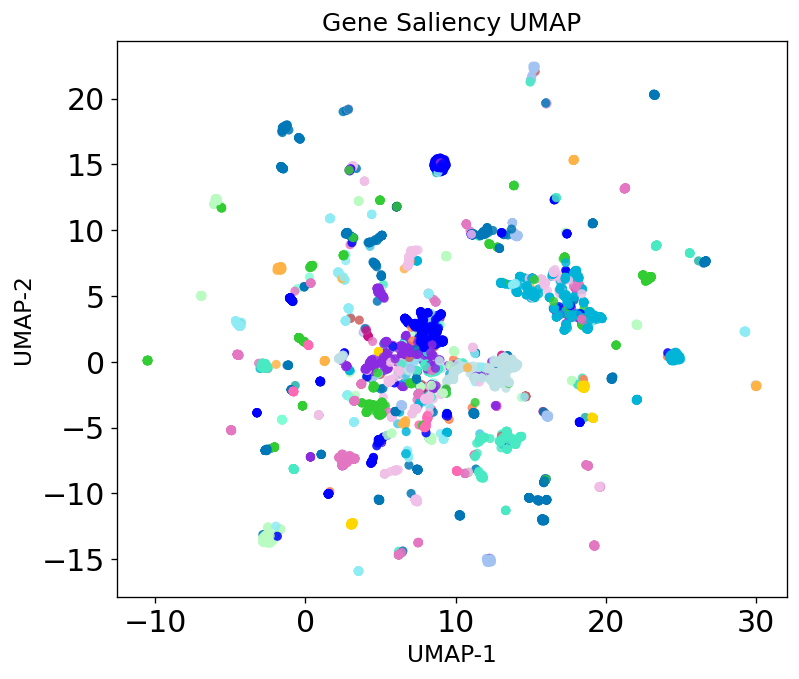

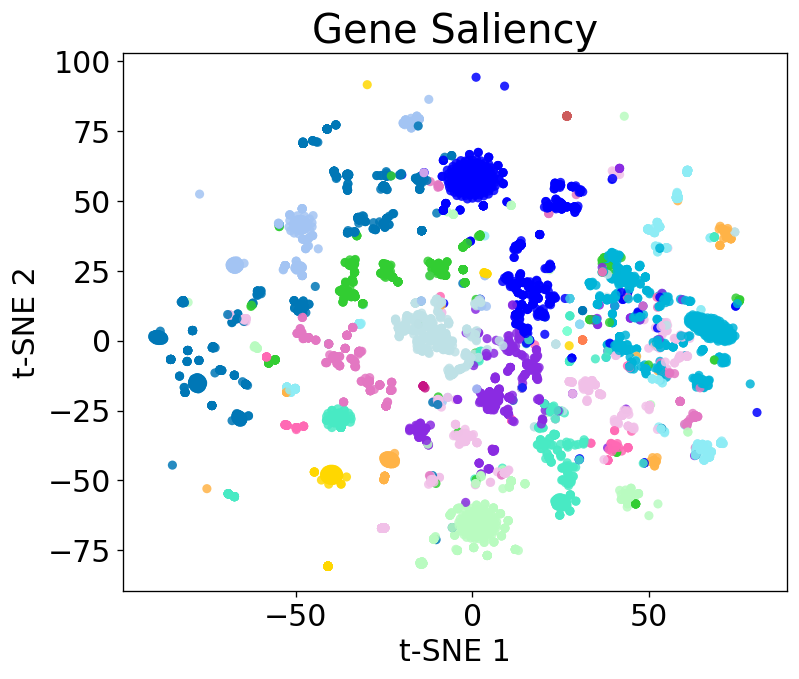

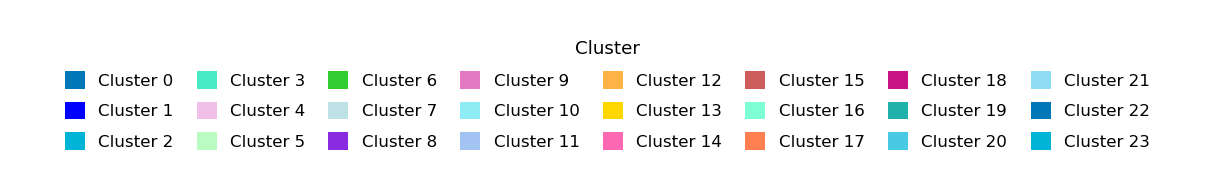

/Users/ericsali/miniforge3/envs/kg39/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



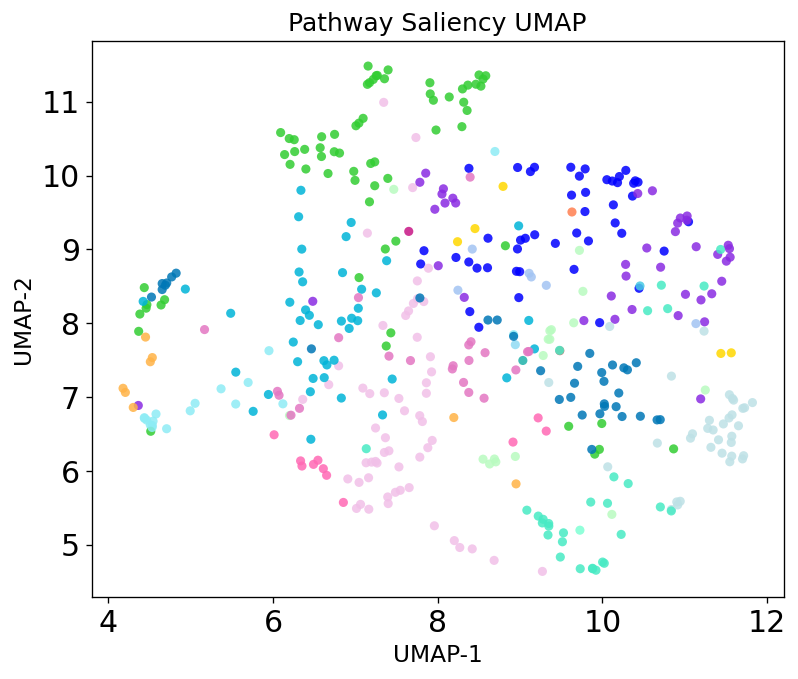

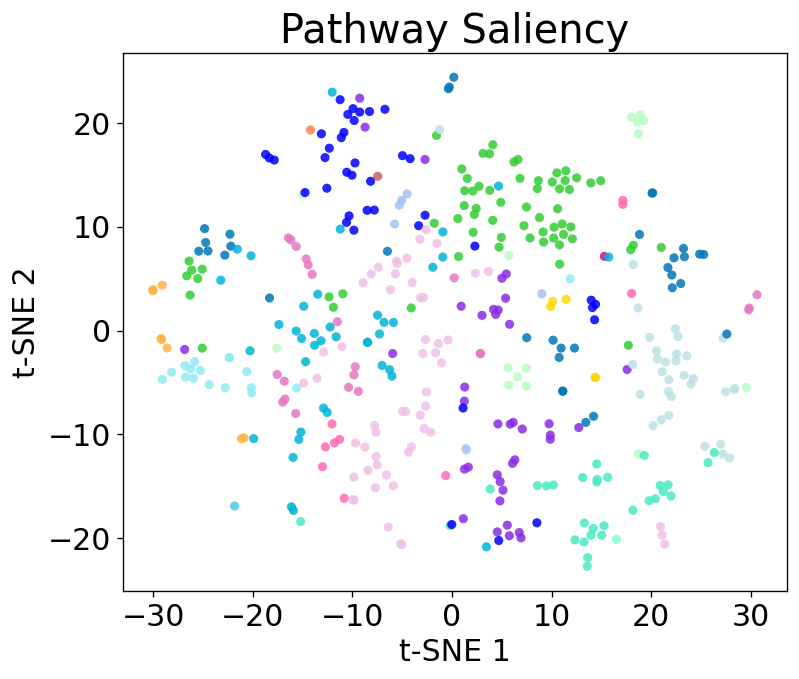

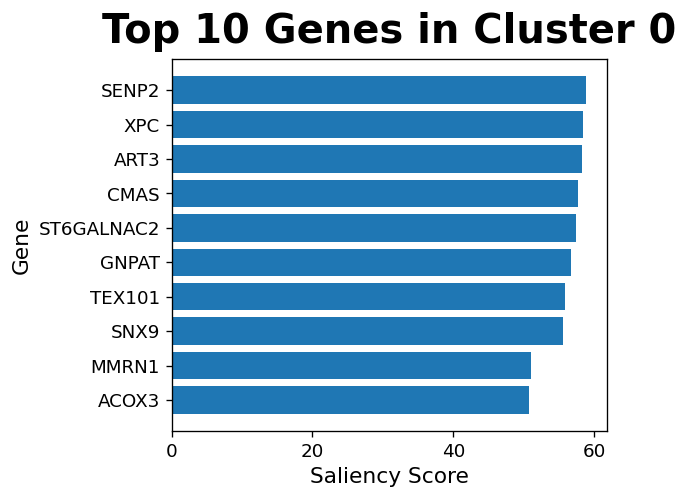

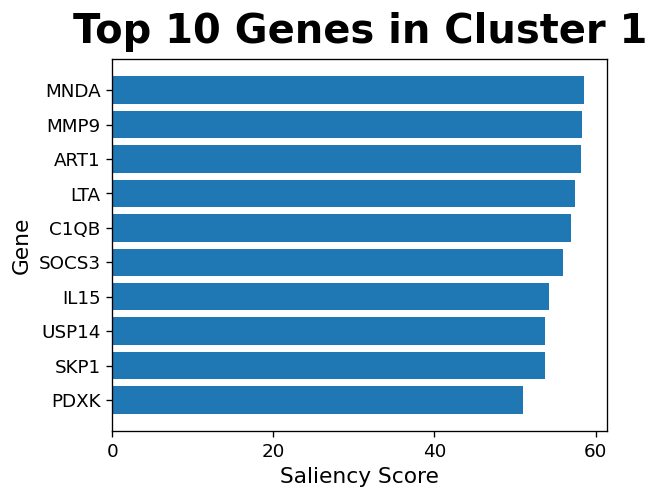

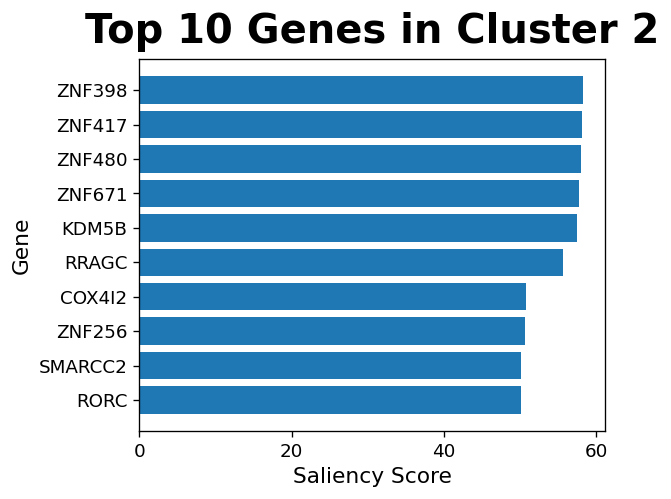

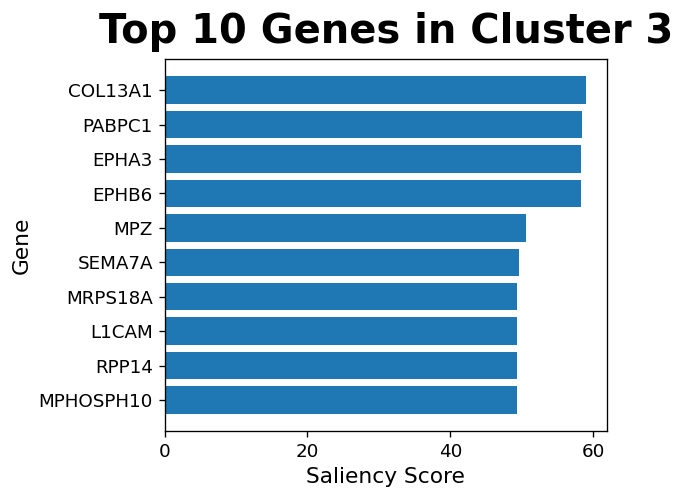

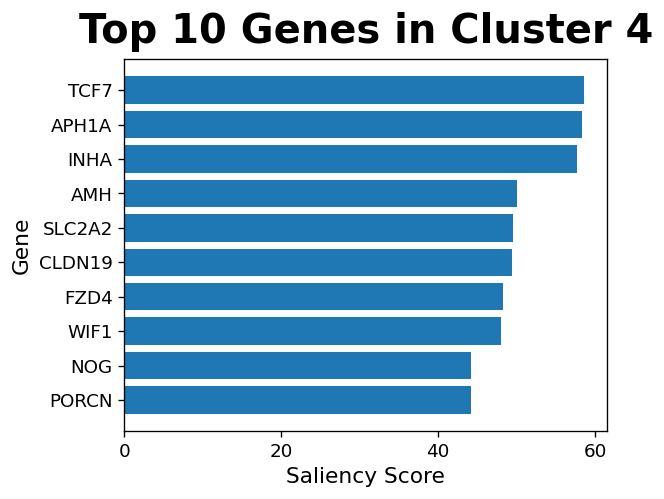

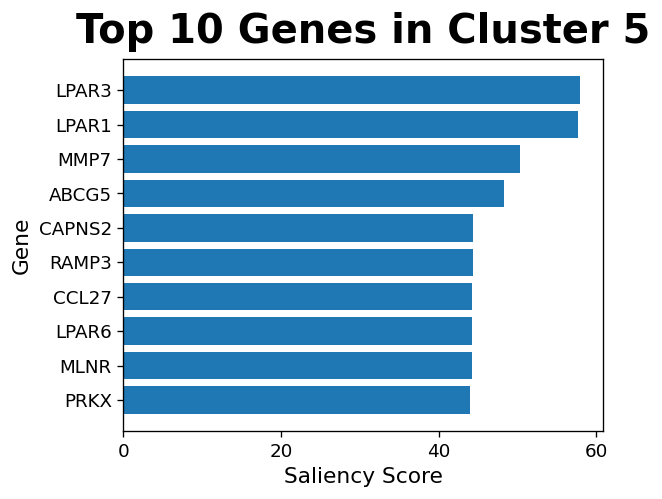

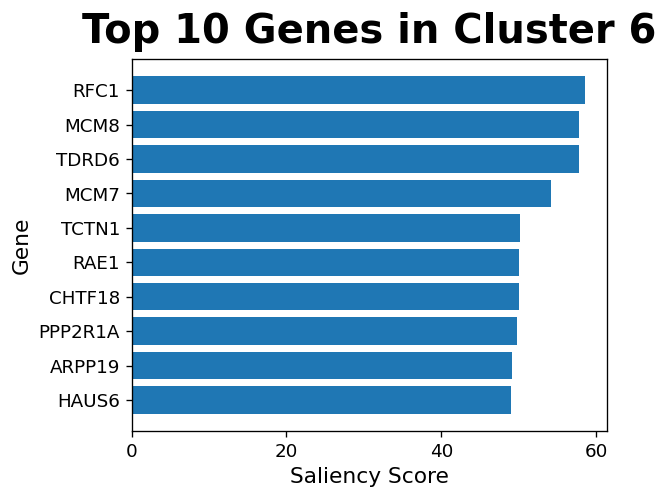

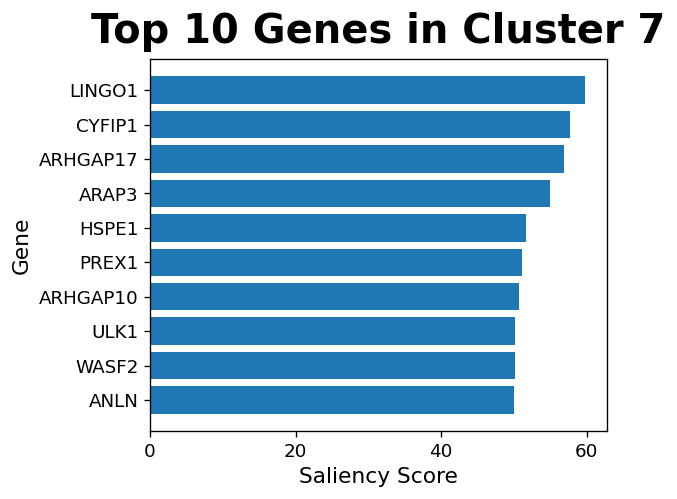

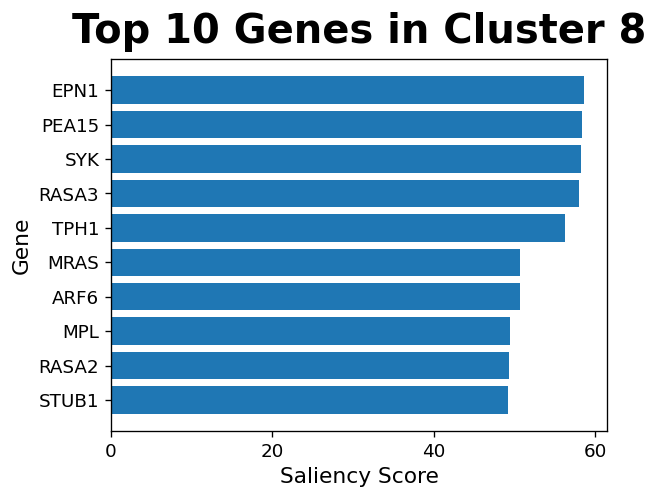

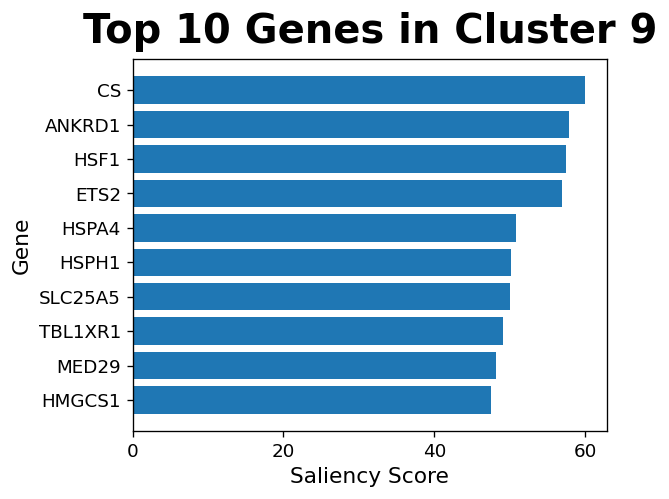

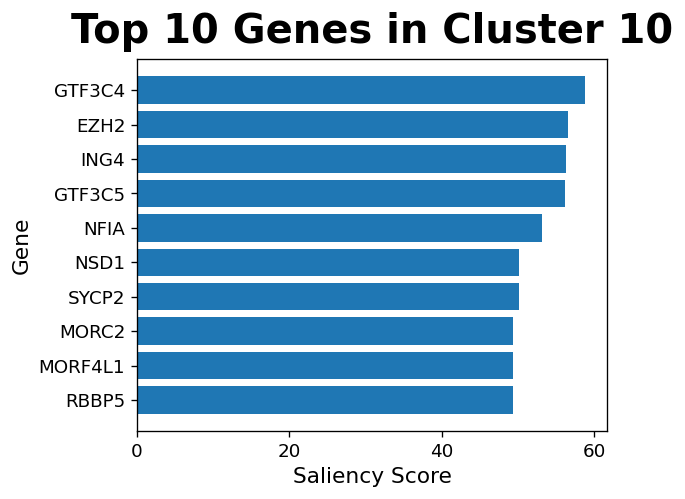

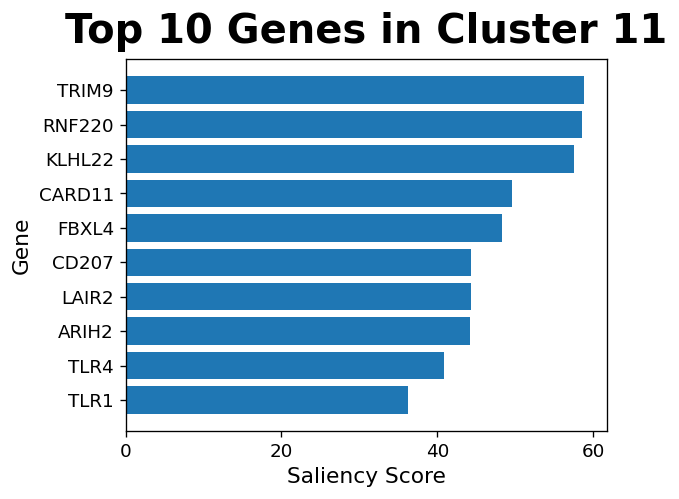

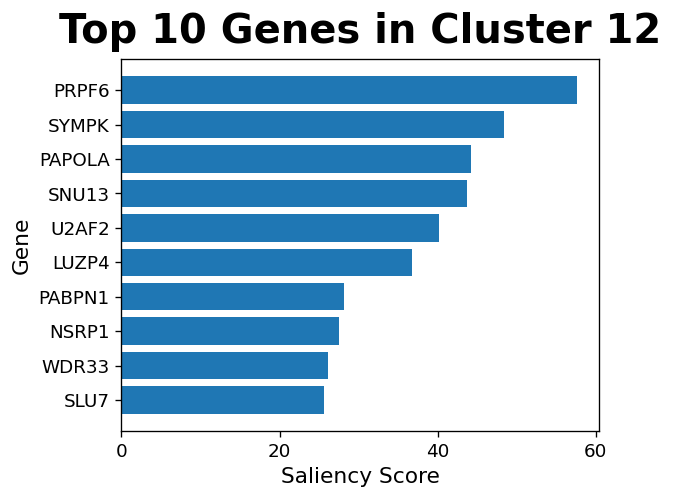

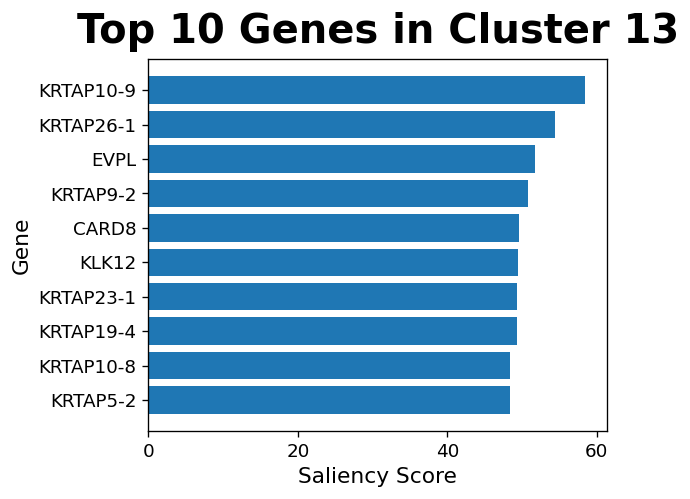

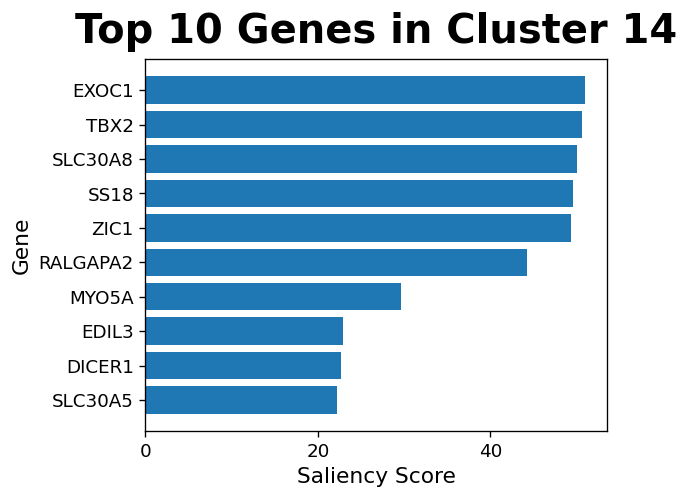

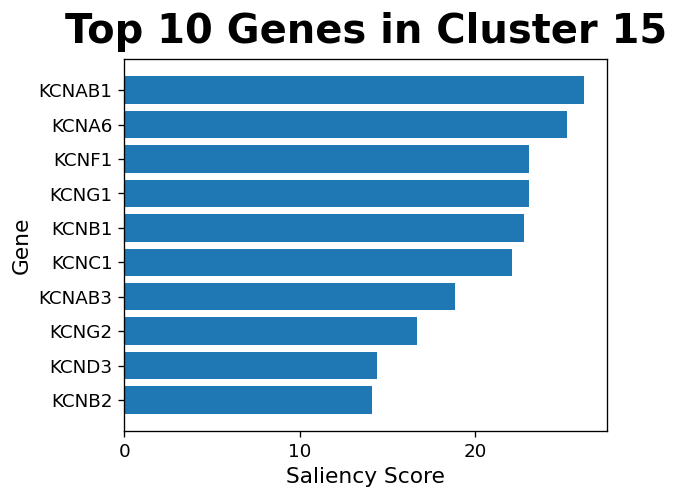

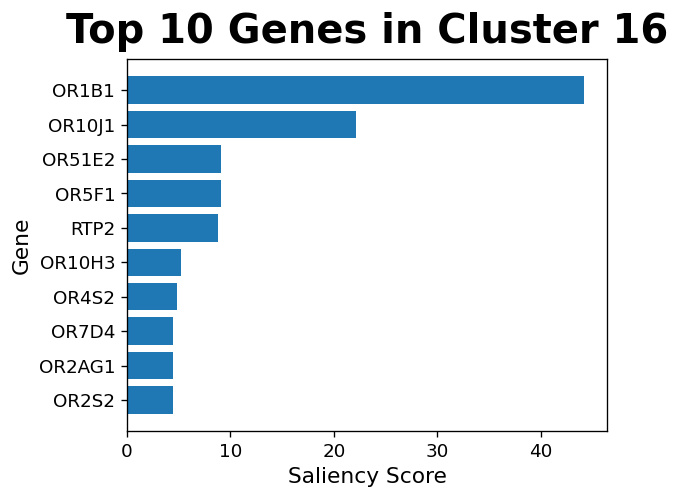

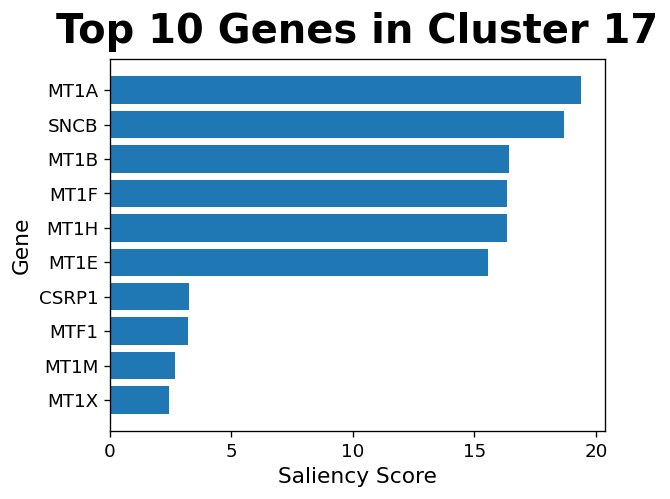

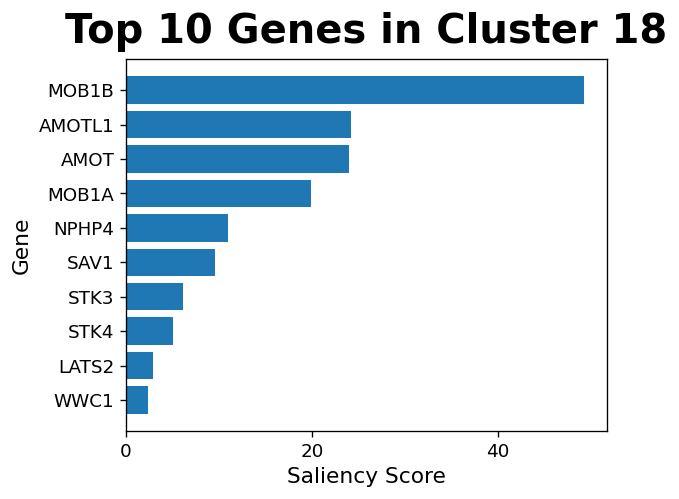

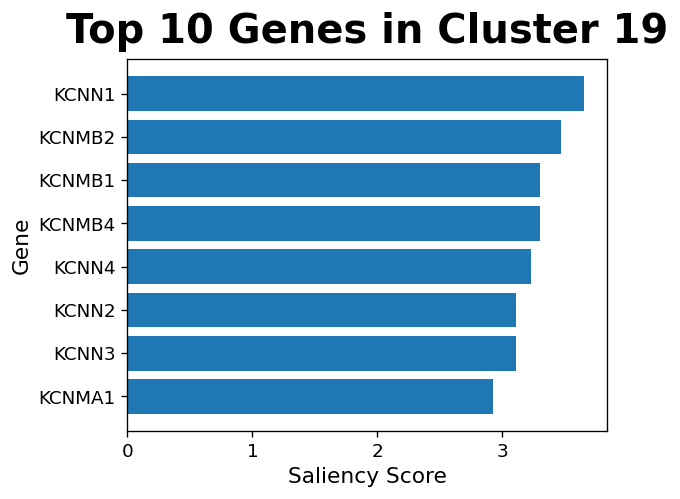

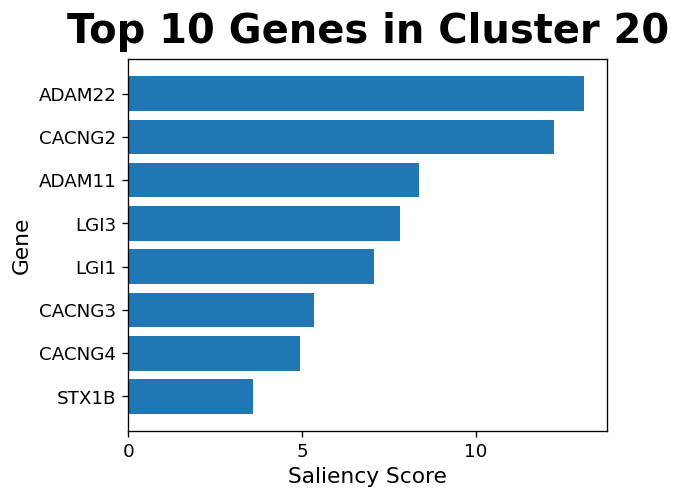

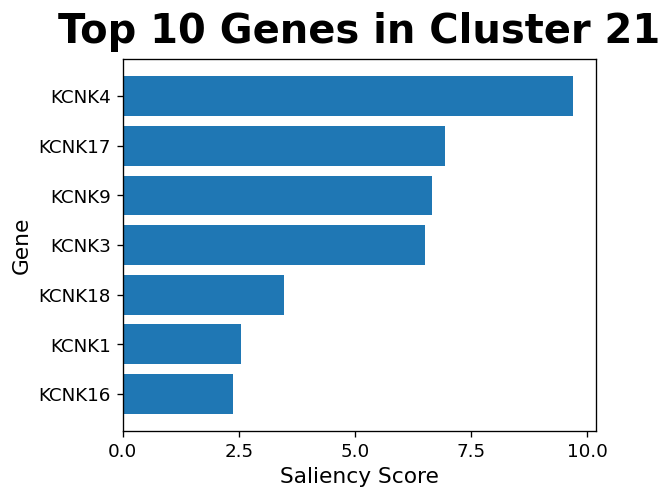

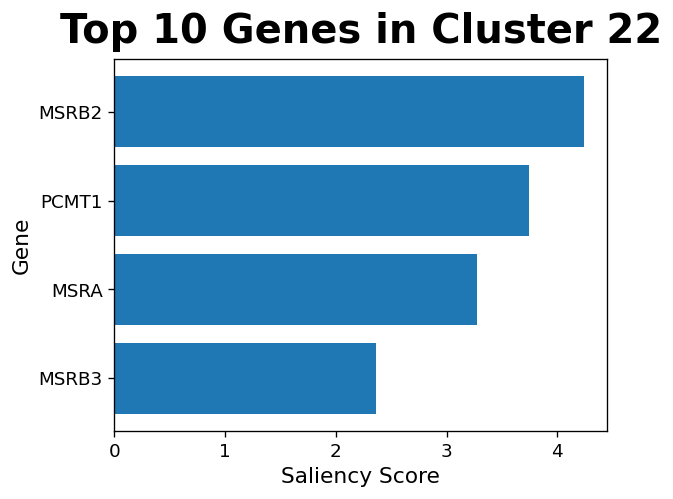

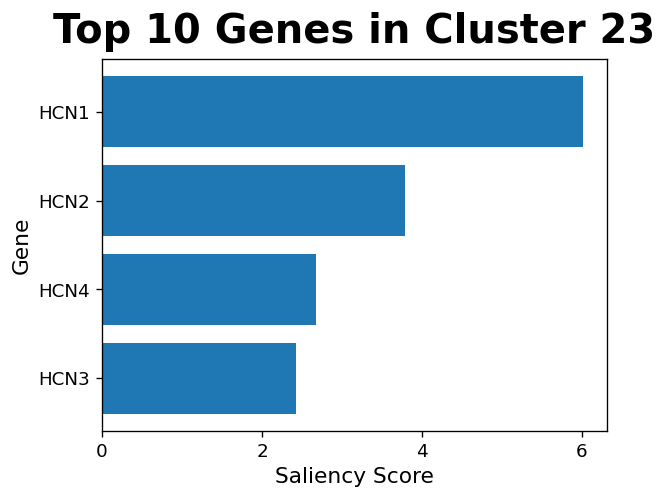

✓ Embedding and cluster plots complete
Analysis pipeline complete.


In [ ]:
# Stage 9/9 — Final visualizations
print('Stage 9/9 — Final visualizations')

gene_saliency = saliency_pathway_matrix.T  # (genes × pathways)
gene_cluster_ids = [gene_clusters[g] for g in gene_names]


print('✓ Preparing embedding visualizations')

gene_umap_file = os.path.join(
    output_path,
    f"gene_umap_leiden"
    f"_dim{args.dim_latent}"
    f"_lay{args.num_layers}"
    f"_epo{args.epochs}.png"
)

plot_umap_with_cluster_colors(
    X=gene_saliency,
    cluster_ids=gene_cluster_ids,
    cluster_colors=CLUSTER_COLORS,
    output_path=output_path,
    filename=os.path.basename(gene_umap_file),
    title="Gene Saliency UMAP",
)


tsne_gene_file = os.path.join(
    output_path,
    f"gene_tsne_leiden"
    f"_dim{args.dim_latent}"
    f"_lay{args.num_layers}"
    f"_hid{args.hidden_size}"
    f"_epo{args.epochs}.png"
)


embedding_tsne = plot_tsne_with_cluster_colors(
    X=gene_saliency,
    cluster_ids=gene_cluster_ids,
    cluster_colors=CLUSTER_COLORS,
    output_path=output_path,
    filename=os.path.basename(tsne_gene_file),
    title="Gene Saliency",
)


plot_cluster_legend(
    CLUSTER_COLORS,
    output_path,
    filename="umap_cluster_legend.png",
    n_rows=3,
)

pathway_saliency = saliency_pathway_matrix  # (pathways × genes)
pathway_cluster_ids = [pathway_clusters[p] for p in pathway_names]

umap_pathway_file = os.path.join(
    output_path,
    f"pathway_umap_leiden"
    f"_dim{args.dim_latent}"
    f"_lay{args.num_layers}"
    f"_hid{args.hidden_size}"
    f"_epo{args.epochs}.png"
)
plot_umap_with_cluster_colors(
    X=pathway_saliency,
    cluster_ids=pathway_cluster_ids,
    cluster_colors=CLUSTER_COLORS,
    output_path=output_path,
    filename=os.path.basename(umap_pathway_file),
    title="Pathway Saliency UMAP",
    point_size=30,
)

tsne_pathway_file = os.path.join(
    output_path,
    f"pathway_tsne_leiden"
    f"_dim{args.dim_latent}"
    f"_lay{args.num_layers}"
    f"_hid{args.hidden_size}"
    f"_epo{args.epochs}.png"
)

embedding_tsne = plot_tsne_with_cluster_colors(
    X=pathway_saliency,
    cluster_ids=pathway_cluster_ids,
    cluster_colors=CLUSTER_COLORS,
    output_path=output_path,
    filename=os.path.basename(tsne_pathway_file),
    title="Pathway Saliency",
)

plot_top_genes_per_cluster(
    gene_saliency=saliency_np,
    gene_names=gene_names,
    gene_clusters=gene_clusters,
    output_path=output_path,
    top_k=10
)

print('✓ Embedding and cluster plots complete')
print("Analysis pipeline complete.")
